In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
# !pip install ydata-profiling

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/Projects/Real Estate Capstone Project/DataSets/Cleaned_Pre-Processing/final_cleaned_mumbai_real_estate_.csv')
df.head()

,flat_type,price,age_of_property,possesion_status,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities
0,3 BHK Flat,2.05,15.0,Ready to move,Middle,Moroccan Cooperative,3.0,3.0,3.0,1.0,kaggle,Goregaon East,1862.0,1425.0,True,Semi Furnished,11009.667025,4,NaN,NaN
1,1 BHK Flat,1.33,1.0,Ready to move,Lower,Rajesh White City,1.0,2.0,0.0,1.0,kaggle,Kandivali East,790.0,479.0,True,Unfurnished,16835.443038,1,NaN,NaN
2,3 BHK Flat,7.30,10.0,Ready to move,Lower,Oberoi Esquire,3.0,2.0,0.0,2.0,kaggle,Goregaon East,1430.0,1330.0,True,Unfurnished,51048.951049,3,NaN,NaN
3,3 BHK Flat,7.60,4.0,Ready to move,Higher,Oberoi Esquire,3.0,4.0,0.0,3.0,kaggle,Goregaon East,2195.0,1400.0,True,Semi Furnished,34624.145786,5,NaN,NaN
4,2 BHK Flat,3.20,3.0,Ready to move,Lower,Ajmera Zeon,2.0,2.0,1.0,1.0,kaggle,Wadala East,960.0,860.0,True,Unfurnished,33333.333333,3,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11031 entries, 0 to 11030
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   flat_type           11031 non-null  object 
 1   price               11031 non-null  float64
 2   age_of_property     11031 non-null  float64
 3   possesion_status    11031 non-null  object 
 4   which_floor         11031 non-null  object 
 5   project_name        11031 non-null  object 
 6   bedrooms            11031 non-null  float64
 7   bathrooms           11031 non-null  float64
 8   balcony             11031 non-null  float64
 9   parking             11031 non-null  float64
 10  source              11031 non-null  object 
 11  location            11031 non-null  object 
 12  buildup_area_sqft   11031 non-null  float64
 13  carpet_area_sqft    11031 non-null  float64
 14  is_ready_to_move    11031 non-null  bool   
 15  furnishing          11031 non-null  object 
 16  pric

In [6]:
df.describe()

,price,age_of_property,bedrooms,bathrooms,balcony,parking,buildup_area_sqft,carpet_area_sqft,price_per_sqft,property_score
count,11031.000000,11031.000000,11031.000000,11031.000000,11031.000000,11031.000000,11031.000000,11031.000000,1.103100e+04,11031.000000
mean,3.384211,6.828755,2.225999,2.282023,0.600218,1.314659,1118.891216,839.341311,2.549334e+04,2.233433
std,5.171705,6.889485,1.004143,0.846604,1.063486,0.779283,690.299908,484.568338,2.746944e+04,1.488363
min,0.080000,0.000000,0.000000,1.000000,0.000000,0.000000,180.000000,150.000000,1.481481e+03,0.000000
25%,1.070000,2.000000,1.000000,2.000000,0.000000,1.000000,650.000000,450.000000,1.588196e+04,1.000000
50%,2.000000,5.000000,2.000000,2.000000,0.000000,1.000000,915.000000,690.000000,2.197802e+04,2.000000
75%,3.755000,10.000000,3.000000,3.000000,1.000000,2.000000,1395.000000,1073.000000,3.030915e+04,3.000000
max,98.610000,99.000000,7.000000,8.000000,7.000000,8.000000,10000.000000,8000.000000,1.448000e+06,7.000000


In [7]:
total_duplicates = df.duplicated().sum()
print(f"Total exact row duplicates: {total_duplicates}")

if total_duplicates > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=['project_name', 'price']).head(10))
else:
    print("No exact duplicates found. The previous result shows different units (likely different prices/areas) within the same projects.")

Total exact row duplicates: 981


,flat_type,price,age_of_property,possesion_status,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities
952,1 BHK Flat,0.34,8.0,Ready to move,Middle,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,0.0,kaggle,Virar West,450.0,425.0,True,Semi Furnished,7555.555556,2,NaN,NaN
7461,1 BHK Flat,0.34,8.0,Ready to move,Middle,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,0.0,kaggle,Virar West,450.0,425.0,True,Semi Furnished,7555.555556,2,NaN,NaN
10736,1 BHK Flat,0.34,8.0,Ready to move,Middle,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,0.0,kaggle,Virar West,450.0,425.0,True,Semi Furnished,7555.555556,2,NaN,NaN
7870,1 BHK Flat,0.72,10.0,Ready to move,Higher,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,2.0,kaggle,Bhayandar East,760.0,425.0,True,Fully Furnished,9473.684211,3,NaN,NaN
10235,1 BHK Flat,0.72,10.0,Ready to move,Higher,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,2.0,kaggle,Bhayandar East,760.0,425.0,True,Fully Furnished,9473.684211,3,NaN,NaN
659,1 BHK Flat,0.78,5.0,Ready to move,Middle,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,1.0,kaggle,Mira Road East,655.0,425.0,True,Unknown,11908.396947,0,NaN,NaN
9894,1 BHK Flat,0.78,5.0,Ready to move,Middle,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,1.0,kaggle,Mira Road East,655.0,425.0,True,Unknown,11908.396947,0,NaN,NaN
167,2 BHK Flat,0.80,15.0,Ready to move,Higher,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,1.0,kaggle,Goregaon East,764.0,690.0,True,Unfurnished,10471.204188,1,NaN,NaN
4362,2 BHK Flat,0.80,15.0,Ready to move,Higher,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,1.0,kaggle,Goregaon East,764.0,690.0,True,Unfurnished,10471.204188,1,NaN,NaN
5139,1 BHK Flat,0.80,5.0,Ready to move,Middle,1.0 Lac(Negotiable)Access Zero Brokerage Properties,2.0,2.0,0.0,1.0,kaggle,Mira Road East,650.0,425.0,True,Semi Furnished,12307.692308,2,NaN,NaN


In [8]:
initial_shape = df.shape
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Original number of rows: {initial_shape[0]}")
print(f"Rows after removing duplicates: {df.shape[0]}")
print(f"Total rows removed: {initial_shape[0] - df.shape[0]}")

Original number of rows: 11031
Rows after removing duplicates: 10050
Total rows removed: 981


# Numerical Univariate Analysis


## flat_type

In [9]:
df[df['flat_type'].str.contains('5+', regex=False)]

,flat_type,price,age_of_property,possesion_status,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities
1240,5+ BHK Flat,8.5,15.0,Ready to move,Higher,Nathani Residency,6.0,7.0,3.0,0.0,kaggle,Agripada,3000.0,2600.0,True,Unfurnished,28333.333333,3,NaN,NaN


In [10]:
# Converting 5+ to 5 since only single value
df.loc[1240,'flat_type']= '5'

In [11]:
df['flat_type'] = df['flat_type'].str.split(" ").str.get(0).astype(float)

In [12]:
df.head()

,flat_type,price,age_of_property,possesion_status,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities
0,3.0,2.05,15.0,Ready to move,Middle,Moroccan Cooperative,3.0,3.0,3.0,1.0,kaggle,Goregaon East,1862.0,1425.0,True,Semi Furnished,11009.667025,4,NaN,NaN
1,1.0,1.33,1.0,Ready to move,Lower,Rajesh White City,1.0,2.0,0.0,1.0,kaggle,Kandivali East,790.0,479.0,True,Unfurnished,16835.443038,1,NaN,NaN
2,3.0,7.30,10.0,Ready to move,Lower,Oberoi Esquire,3.0,2.0,0.0,2.0,kaggle,Goregaon East,1430.0,1330.0,True,Unfurnished,51048.951049,3,NaN,NaN
3,3.0,7.60,4.0,Ready to move,Higher,Oberoi Esquire,3.0,4.0,0.0,3.0,kaggle,Goregaon East,2195.0,1400.0,True,Semi Furnished,34624.145786,5,NaN,NaN
4,2.0,3.20,3.0,Ready to move,Lower,Ajmera Zeon,2.0,2.0,1.0,1.0,kaggle,Wadala East,960.0,860.0,True,Unfurnished,33333.333333,3,NaN,NaN


In [13]:
def basic_info(df):
  print(df.info(),"\n")
  print(df.describe(),"\n")
  print("Null: ",df.isna().sum(),"\n")
  print(f"Skewness: {df.skew()}\n Kurtosis: {df.kurtosis()}\n")
  print("Duplicates: ",df.duplicated().sum(),"\n")

In [14]:
basic_info(df['flat_type'])

<class 'pandas.core.series.Series'>
RangeIndex: 10050 entries, 0 to 10049
Series name: flat_type
Non-Null Count  Dtype  
--------------  -----  
10050 non-null  float64
dtypes: float64(1)
memory usage: 78.6 KB
None 

count    10050.000000
mean         2.187214
std          1.023823
min          0.500000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: flat_type, dtype: float64 

Null:  0 

Skewness: 0.6308365700554195
 Kurtosis: 0.19906122864259856

Duplicates:  10041 



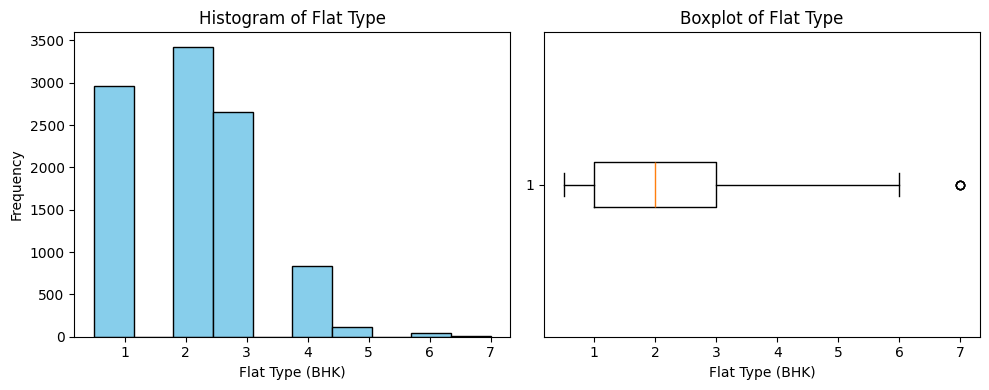

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Histogram using indexing
ax[0].hist(df['flat_type'], bins=10, color='skyblue', edgecolor='black')
ax[0].set_title('Histogram of Flat Type')
ax[0].set_xlabel('Flat Type (BHK)')
ax[0].set_ylabel('Frequency')

# Boxplot using indexing
ax[1].boxplot(df['flat_type'], vert=False)
ax[1].set_title('Boxplot of Flat Type')
ax[1].set_xlabel('Flat Type (BHK)')

plt.tight_layout()
plt.show()

In [16]:
df[df['flat_type']>6]

,flat_type,price,age_of_property,possesion_status,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities
4959,7.0,21.00,2.0,Ready to move,Higher,Lodha Marquise,7.0,5.0,0.0,3.0,kaggle,Worli,3000.0,2900.0,True,Fully Furnished,70000.000000,6,NaN,NaN
8119,7.0,7.50,1.0,Ready to move,Higher,Sheth Montana,7.0,5.0,2.0,6.0,kaggle,Mulund West,6080.0,5700.0,True,Unfurnished,12335.526316,3,NaN,NaN
8836,7.0,98.61,1.5,Ready to move,Unknown,Lodha Sea Face,7.0,5.0,1.0,4.5,99acres,Worli Seaface,4540.0,4300.0,True,Unknown,217202.643172,3,"Luxury amenities: infinity pool, gym, and more | Live the dream at an affordable price with premium finishes | Safety and privacy with 24/7 security and surveillance",Swimming Pool | Gymnasium | Security | CCTV
8993,7.0,87.51,1.5,Ready to move,Unknown,Birla Niyaara,7.0,5.0,1.0,4.5,99acres,Worli,4540.0,4300.0,True,Unknown,192753.303965,3,"Lead Architects and Masterplanners: Foster + Partners (London, UK) | Lounge Bar Terrace is provided | 3 Clubhouses For holistic living",Spa | Pet Area | Club House


In [17]:
df.rename({'flat_type':'bhk'}, axis=1, inplace = True)

- Mean and median are nearly same
- skewness is low
- 4 flats having 7 bhk

## price

In [18]:
basic_info(df['price'])

<class 'pandas.core.series.Series'>
RangeIndex: 10050 entries, 0 to 10049
Series name: price
Non-Null Count  Dtype  
--------------  -----  
10050 non-null  float64
dtypes: float64(1)
memory usage: 78.6 KB
None 

count    10050.000000
mean         3.392533
std          5.274094
min          0.080000
25%          1.070000
50%          2.000000
75%          3.750000
max         98.610000
Name: price, dtype: float64 

Null:  0 

Skewness: 7.474378058569268
 Kurtosis: 87.48821471747603

Duplicates:  9103 



In [19]:
df[df['price']>=90]

,bhk,price,age_of_property,possesion_status,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities
5265,6.0,91.98,4.0,Ready to move,Unknown,25 South,6.0,6.0,0.0,4.0,99acres,Prabhadevi,2872.5,2600.0,True,Unknown,320208.877285,3,"Oversized land parcels, closest to the Sea, sea-facing flats | Eastern Express Highway connectivity with 2.5 km | Less ground coverage area, more open space",Pet Area | Spa
8836,7.0,98.61,1.5,Ready to move,Unknown,Lodha Sea Face,7.0,5.0,1.0,4.5,99acres,Worli Seaface,4540.0,4300.0,True,Unknown,217202.643172,3,"Luxury amenities: infinity pool, gym, and more | Live the dream at an affordable price with premium finishes | Safety and privacy with 24/7 security and surveillance",Swimming Pool | Gymnasium | Security | CCTV


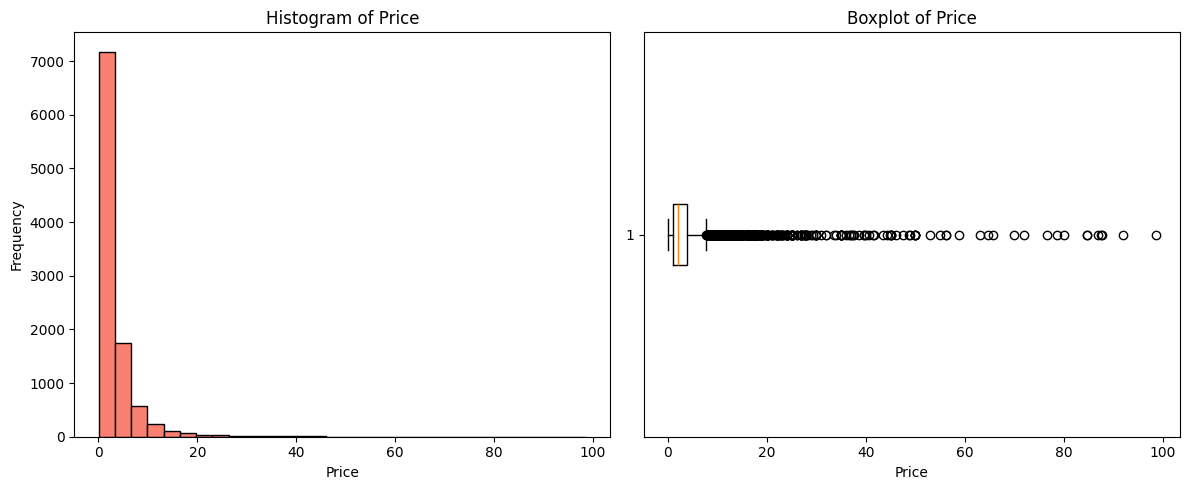

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Price
ax[0].hist(df['price'], bins=30, color='salmon', edgecolor='black')
ax[0].set_title('Histogram of Price')
ax[0].set_xlabel('Price')
ax[0].set_ylabel('Frequency')

# Boxplot for Price
ax[1].boxplot(df['price'], vert=False)
ax[1].set_title('Boxplot of Price')
ax[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

- High skewness and kurtosis
- Too many outliers

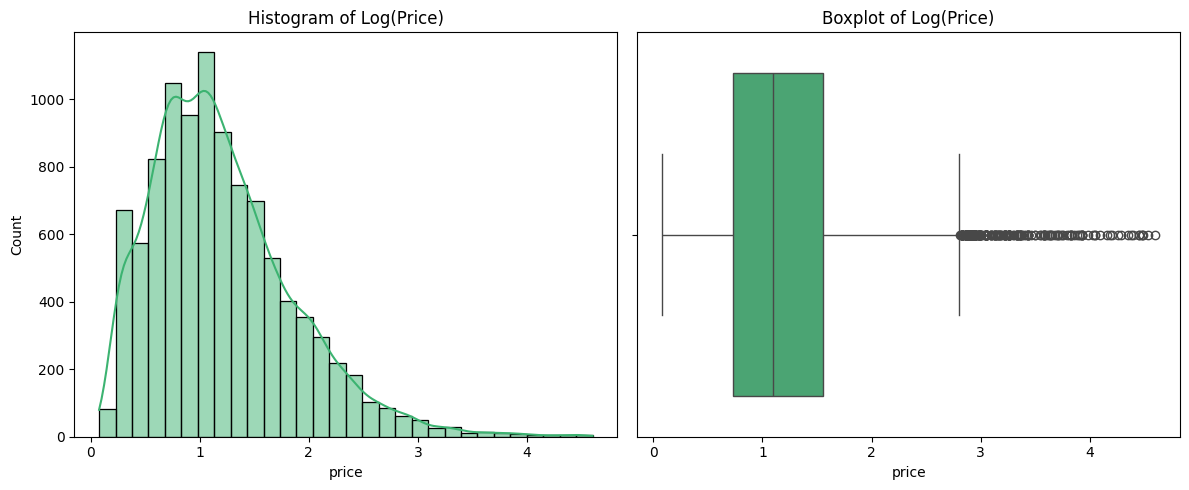

Original Skewness: 7.47
Log-Transformed Skewness: 1.02


In [21]:
import numpy as np

# Apply log1p transformation to handle skewness
price_log = np.log1p(df['price'])

# Visualize the transformed distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Log Price
sns.histplot(price_log, bins=30, kde=True, color='mediumseagreen', ax=ax[0])
ax[0].set_title('Histogram of Log(Price)')

# Boxplot for Log Price
sns.boxplot(x=price_log, color='mediumseagreen', ax=ax[1])
ax[1].set_title('Boxplot of Log(Price)')

plt.tight_layout()
plt.show()

# Check new skewness and kurtosis
print(f"Original Skewness: {df['price'].skew():.2f}")
print(f"Log-Transformed Skewness: {price_log.skew():.2f}")

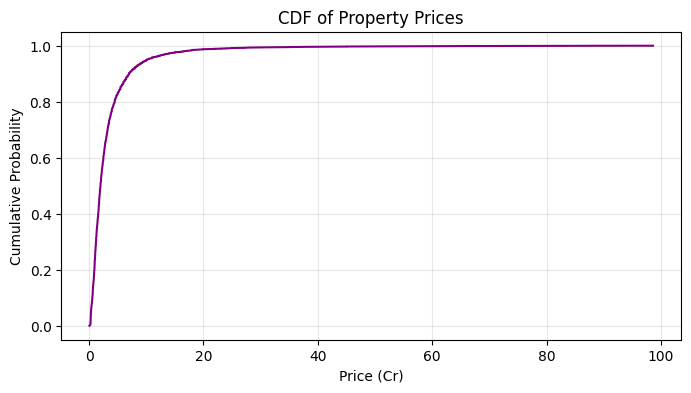

Price Deciles (Cr):
0.0     0.080
0.1     0.599
0.2     0.950
0.3     1.220
0.4     1.600
0.5     2.000
0.6     2.500
0.7     3.250
0.8     4.500
0.9     7.000
1.0    98.610
Name: price, dtype: float64


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# CDF
cdf = df['price'].sort_values().reset_index(drop=True)

plt.figure(figsize=(8,4))
plt.plot(cdf, np.linspace(0, 1, len(cdf)), color='purple')
plt.title('CDF of Property Prices')
plt.xlabel('Price (Cr)')
plt.ylabel('Cumulative Probability')
plt.grid(alpha=0.3)
plt.show()

# Deciles
print("Price Deciles (Cr):")
print(df['price'].quantile(np.arange(0, 1.1, 0.1)))


- **Extreme Skewness:** Price distribution is heavily right-skewed (7.36) due to ultra-luxury properties like the ~99 Cr outliers.
- **Value Concentration:** The top 10% of properties (priced > 7 Cr) hold nearly 41% of the total market value.
- **Market Median:** 50% of the properties in Mumbai are priced at 2 Cr or below.
- **Transformation:** Log transformation successfully normalized the distribution for future modeling (skewness reduced to 0.99).

## age_of_property

In [23]:
basic_info(df['age_of_property'])

<class 'pandas.core.series.Series'>
RangeIndex: 10050 entries, 0 to 10049
Series name: age_of_property
Non-Null Count  Dtype  
--------------  -----  
10050 non-null  float64
dtypes: float64(1)
memory usage: 78.6 KB
None 

count    10050.000000
mean         6.895622
std          6.869184
min          0.000000
25%          2.000000
50%          5.000000
75%         10.000000
max         99.000000
Name: age_of_property, dtype: float64 

Null:  0 

Skewness: 2.42172904905148
 Kurtosis: 11.225702260240586

Duplicates:  10000 



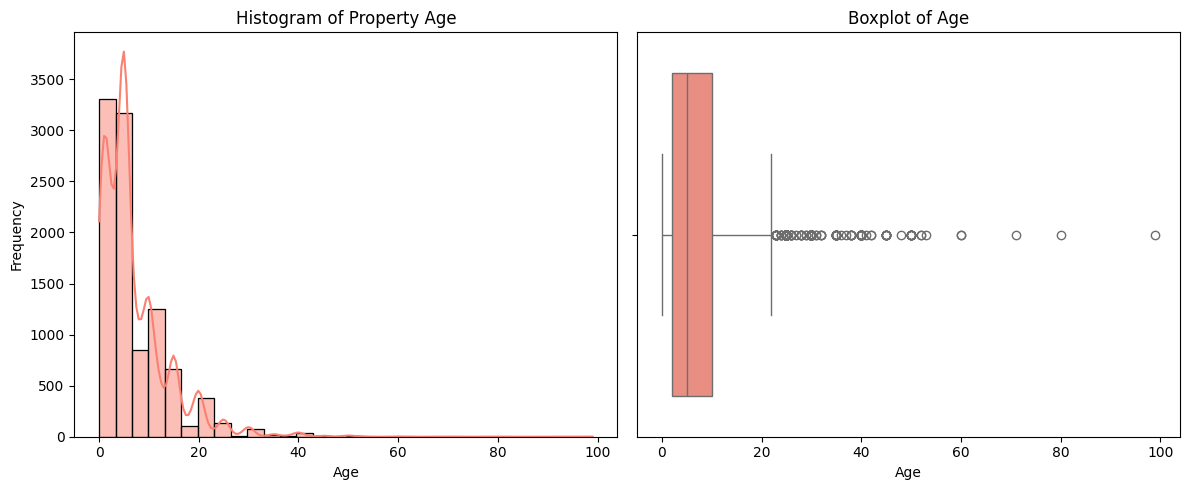

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['age_of_property'], bins=30, color='salmon', kde=True, ax=ax[0])
ax[0].set_title('Histogram of Property Age')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Frequency')

sns.boxplot(x=df['age_of_property'], color='salmon', ax=ax[1])
ax[1].set_title('Boxplot of Age')
ax[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

In [25]:
print(f"Total properties > 20 years: {(df['age_of_property'] > 20).sum()}")
print(f"Percentage of dataset: {((df['age_of_property'] > 20).sum() / len(df)) * 100:.2f}%")

print("\nBreakdown of older properties:")
older_bins = pd.cut(df[df['age_of_property'] > 20]['age_of_property'],
                    bins=[20, 40, 60, 100])
print(older_bins.value_counts().sort_index())

Total properties > 20 years: 353
Percentage of dataset: 3.51%

Breakdown of older properties:
age_of_property
(20, 40]     324
(40, 60]      26
(60, 100]      3
Name: count, dtype: int64


- **Newer Inventory:** The market is dominated by relatively new properties, with a median age of just **5 years**.
- **Right Skewed:** The distribution is right-skewed (2.37), indicating that while most homes are new, there is a 'long tail' of older buildings.
- **Outliers:** There are significant outliers with ages up to **99 years**, which likely represent heritage buildings or very old redeveloped societies.
- **Market Bulk:** 75% of the listed properties are **10 years old or less**, showing a strong preference for recent constructions in the current market listings.
- **Outliers:** Total properties > 20 years: 390. Most of them lie in the range of 20-40

##  bedrooms, bathrooms, balcony, and parking

BEDROOMS
Unique values: [3. 1. 2. 5. 6. 4. 0. 7.]
bedrooms
0.0     0.009950
1.0    25.880597
2.0    38.606965
3.0    25.512438
4.0     7.970149
5.0     1.442786
6.0     0.517413
7.0     0.059701
Name: proportion, dtype: float64


BATHROOMS
Unique values: [3. 2. 4. 1. 6. 5. 7. 8.]
bathrooms
1.0    12.507463
2.0    56.477612
3.0    22.577114
4.0     7.114428
5.0     0.875622
6.0     0.358209
7.0     0.079602
8.0     0.009950
Name: proportion, dtype: float64


BALCONY
Unique values: [3. 0. 1. 4. 2. 5. 7. 6.]
balcony
0.0    67.611940
1.0    13.164179
2.0     9.512438
3.0     7.601990
4.0     1.711443
5.0     0.328358
6.0     0.039801
7.0     0.029851
Name: proportion, dtype: float64


PARKING
Unique values: [1.  2.  3.  0.  4.  5.  6.  8.  7.  4.5]
parking
0.0     8.467662
1.0    59.034826
2.0    26.935323
3.0     4.069652
4.0     1.064677
4.5     0.019900
5.0     0.228856
6.0     0.129353
7.0     0.019900
8.0     0.029851
Name: proportion, dtype: float64




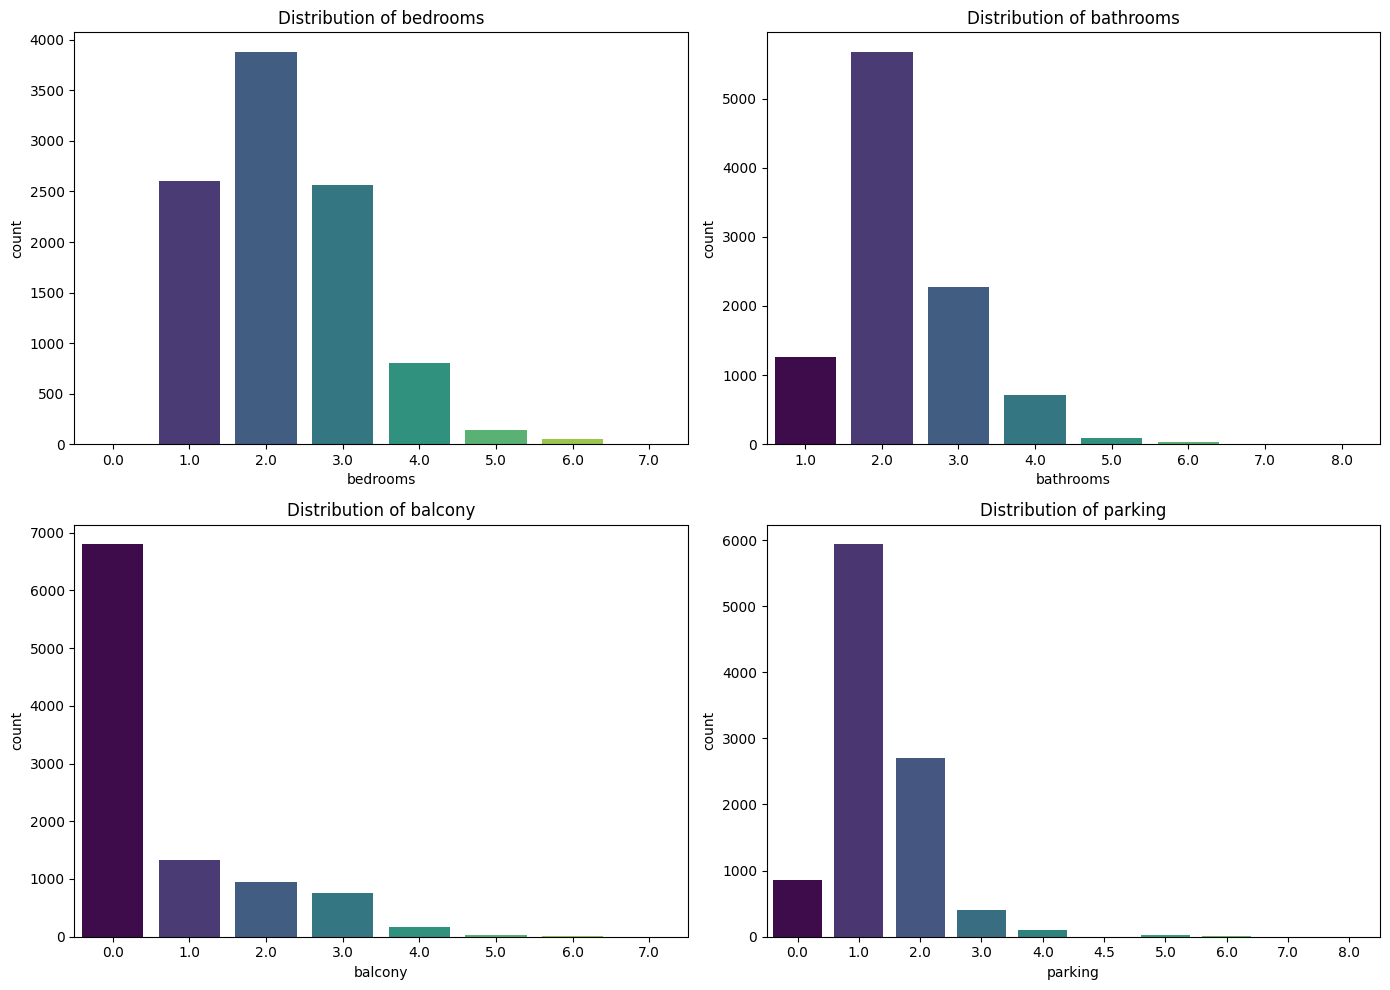

In [26]:
discrete_cols = ['bedrooms', 'bathrooms', 'balcony', 'parking']

for col in discrete_cols:
    print(f"{col.upper()}")
    print(f"Unique values: {df[col].unique()}")
    print(df[col].value_counts(normalize=True).sort_index() * 100)
    print("\n")

# Visualize the distribution of these discrete counts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

- **Bedrooms & Bathrooms:** The market is centered around 1, 2, and 3 BHK configurations, with 2-bathroom setups being the overwhelming standard (56%).
- **Balcony Data:** A significant majority (70%) of listings report 0 balconies. This may require further investigation to see if it's missing data or literal.
- **Parking:** 1-parking spot is the most frequent (60%), followed by 2-parking spots (26%).

## source

In [27]:
print("Source Distribution (%):")
print(df['source'].value_counts(normalize=True) * 100)

# checkin if 'unknown' furnishing belongs to a specific source or not
print("\nFurnishing status by Source:")
display(pd.crosstab(df['source'], df['furnishing']))

Source Distribution (%):
source
kaggle     88.686567
99acres    11.313433
Name: proportion, dtype: float64

Furnishing status by Source:


furnishing,Fully Furnished,Semi Furnished,Unfurnished,Unknown
source,,,,
99acres,0,0,0,1137
kaggle,974,3334,2857,1748


### Source Analysis Insights
- **Kaggle Dominance:** ~90% of the total data comes from the Kaggle source.
- **99acres Missing Data:** 100% of properties sourced from 99acres have an 'Unknown' furnishing status, indicating a source-specific data gap.
- **Furnishing Mix:** Kaggle listings provide a diverse mix of furnishing types (Fully/Semi/Unfurnished), whereas 99acres provides zero visibility into this feature.

In [28]:
df.head()

,bhk,price,age_of_property,possesion_status,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities
0,3.0,2.05,15.0,Ready to move,Middle,Moroccan Cooperative,3.0,3.0,3.0,1.0,kaggle,Goregaon East,1862.0,1425.0,True,Semi Furnished,11009.667025,4,NaN,NaN
1,1.0,1.33,1.0,Ready to move,Lower,Rajesh White City,1.0,2.0,0.0,1.0,kaggle,Kandivali East,790.0,479.0,True,Unfurnished,16835.443038,1,NaN,NaN
2,3.0,7.30,10.0,Ready to move,Lower,Oberoi Esquire,3.0,2.0,0.0,2.0,kaggle,Goregaon East,1430.0,1330.0,True,Unfurnished,51048.951049,3,NaN,NaN
3,3.0,7.60,4.0,Ready to move,Higher,Oberoi Esquire,3.0,4.0,0.0,3.0,kaggle,Goregaon East,2195.0,1400.0,True,Semi Furnished,34624.145786,5,NaN,NaN
4,2.0,3.20,3.0,Ready to move,Lower,Ajmera Zeon,2.0,2.0,1.0,1.0,kaggle,Wadala East,960.0,860.0,True,Unfurnished,33333.333333,3,NaN,NaN


## buildup_area_sqft

In [29]:
basic_info(df['buildup_area_sqft'])

<class 'pandas.core.series.Series'>
RangeIndex: 10050 entries, 0 to 10049
Series name: buildup_area_sqft
Non-Null Count  Dtype  
--------------  -----  
10050 non-null  float64
dtypes: float64(1)
memory usage: 78.6 KB
None 

count    10050.000000
mean      1121.776219
std        687.565707
min        180.000000
25%        650.000000
50%        923.000000
75%       1400.000000
max      10000.000000
Name: buildup_area_sqft, dtype: float64 

Null:  0 

Skewness: 3.106499538195124
 Kurtosis: 19.80387298186431

Duplicates:  8904 



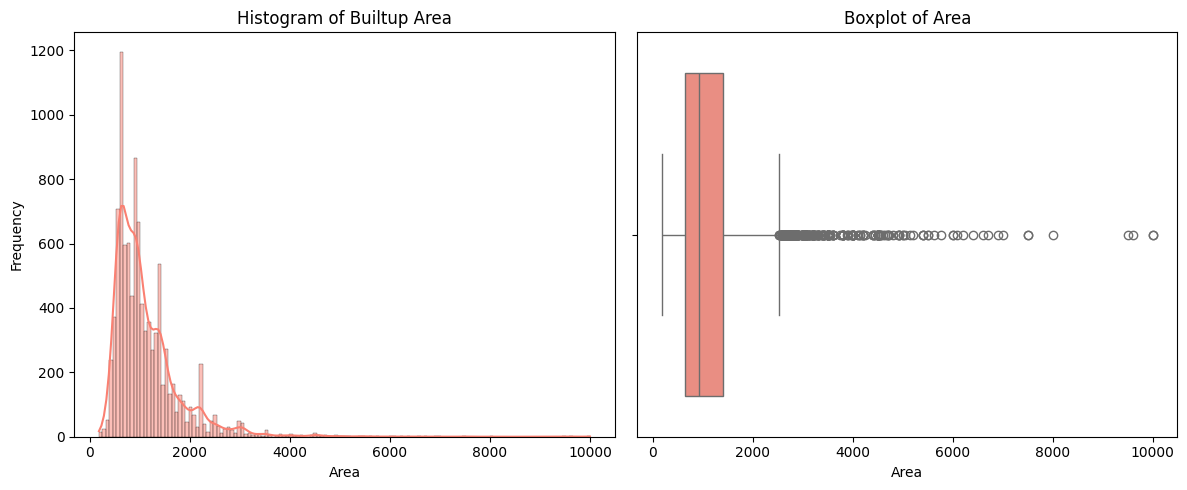

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['buildup_area_sqft'], color='salmon', kde=True, ax=ax[0])
ax[0].set_title('Histogram of Builtup Area')
ax[0].set_xlabel('Area')
ax[0].set_ylabel('Frequency')

sns.boxplot(x=df['buildup_area_sqft'], color='salmon', ax=ax[1])
ax[1].set_title('Boxplot of Area')
ax[1].set_xlabel('Area')

plt.tight_layout()
plt.show()

In [31]:
print(f"Total properties > 2200 sqft area: {(df['buildup_area_sqft'] > 2200).sum()}")
print(f"Percentage of dataset: {((df['buildup_area_sqft'] > 2200).sum() / len(df)) * 100:.2f}%")

print("\nBreakdown area of properties:")
older_bins = pd.cut(df[df['buildup_area_sqft'] > 2200]['buildup_area_sqft'],
                    bins=[2200, 5000, 8000, 11000])
print(older_bins.value_counts().sort_index())

Total properties > 2200 sqft area: 568
Percentage of dataset: 5.65%

Breakdown area of properties:
buildup_area_sqft
(2200, 5000]     542
(5000, 8000]      22
(8000, 11000]      4
Name: count, dtype: int64


In [32]:
# Grouping by BHK to see typical area ranges
area_by_bhk = df.groupby('bhk')['buildup_area_sqft'].agg(['mean', 'median', 'min', 'max'])
print("\nArea stats by BHK configuration:")
display(area_by_bhk)


Area stats by BHK configuration:


,mean,median,min,max
bhk,,,,
0.5,313.866667,300.0,180.0,700.0
1.0,594.437906,600.0,240.0,1116.0
1.5,850.000000,850.0,850.0,850.0
2.0,919.112117,900.0,450.0,2050.0
3.0,1444.261295,1400.0,600.0,4500.0
4.0,2355.097239,2200.0,1000.0,7500.0
5.0,3352.641026,3050.0,1500.0,10000.0
6.0,3652.288889,2872.5,2000.0,10000.0
7.0,4540.000000,4540.0,3000.0,6080.0


### Build-up Area Analysis Insights

- **Mass Market Focus:** The median property size is **915 sqft**, with 75% of properties being under **1,395 sqft**, reflecting Mumbai's space-constrained market.
- **Right Skewed:** A high skewness (3.09) indicates a long tail of luxury properties with very large areas.
- **Luxury Outliers:** About **5.7%** of the properties are larger than 2,200 sqft, with some reaching up to **10,000 sqft**.
- **Configuration Consistency:** The area generally increases with the number of bedrooms (BHK), but the wide range between 'min' and 'max' suggests significant variation in luxury vs. compact segments within the same BHK count.

## carpet_area_sqft

<class 'pandas.core.series.Series'>
RangeIndex: 10050 entries, 0 to 10049
Series name: carpet_area_sqft
Non-Null Count  Dtype  
--------------  -----  
10050 non-null  float64
dtypes: float64(1)
memory usage: 78.6 KB
None 

count    10050.000000
mean       840.707562
std        484.350091
min        150.000000
25%        452.000000
50%        690.000000
75%       1073.000000
max       8000.000000
Name: carpet_area_sqft, dtype: float64 

Null:  0 

Skewness: 2.6780617152080244
 Kurtosis: 18.320342141832818

Duplicates:  9035 



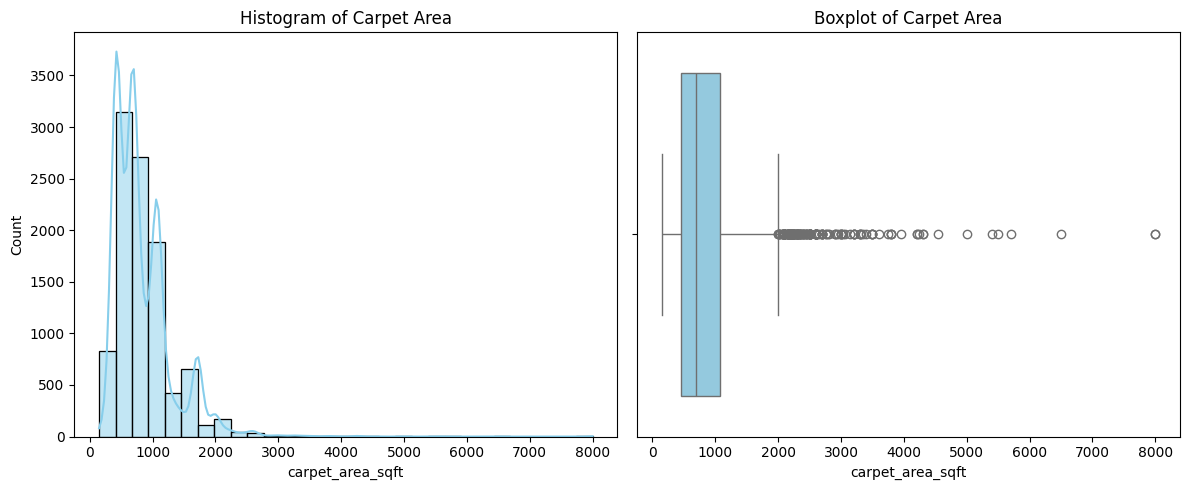

In [33]:
basic_info(df['carpet_area_sqft'])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['carpet_area_sqft'],bins=30, color='skyblue', kde=True, ax=ax[0])
ax[0].set_title('Histogram of Carpet Area')
sns.boxplot(x=df['carpet_area_sqft'], color='skyblue', ax=ax[1])
ax[1].set_title('Boxplot of Carpet Area')
plt.tight_layout()
plt.show()

In [34]:
print(f"Total properties > 2200 sqft area: {(df['carpet_area_sqft'] > 2200).sum()}")
print(f"Percentage of dataset: {((df['carpet_area_sqft'] > 2200).sum() / len(df)) * 100:.2f}%")

print("\nBreakdown of carpet area:")
older_bins = pd.cut(df[df['carpet_area_sqft'] > 2200]['carpet_area_sqft'],
                    bins=[2000, 4000, 6000, 9000])
print(older_bins.value_counts().sort_index)

Total properties > 2200 sqft area: 133
Percentage of dataset: 1.32%

Breakdown of carpet area:
<bound method Series.sort_index of carpet_area_sqft
(2000, 4000]    120
(4000, 6000]     10
(6000, 9000]      3
Name: count, dtype: int64>


In [35]:
# Analyzing the ratio between carpet area and buildup area
area_ratio = df['carpet_area_sqft'] / df['buildup_area_sqft']
print(f"Average Carpet-to-Buildup Ratio: {area_ratio.mean():.2f}")
print(f"Median Carpet-to-Buildup Ratio: {area_ratio.median():.2f}")

Average Carpet-to-Buildup Ratio: 0.76
Median Carpet-to-Buildup Ratio: 0.77


### Carpet Area Analysis Insights

- **Efficiency Ratio:** The median carpet-to-buildup ratio is **0.77**, which is standard for Mumbai real estate, suggesting that about 23% of the build-up area is consumed by walls and common areas.
- **Distribution:** Similar to build-up area, the carpet area is right-skewed (**2.64**) with a median of **690 sqft**.
- **Luxury Segment:** While the bulk of the market is under 1,100 sqft, there are extreme outliers reaching up to **8,000 sqft** of carpet area.
- **Data Consistency:** The lack of null values and the consistent ratio suggests that the area data is relatively clean across the dataset.

## price_per_sqft

In [36]:
basic_info(df['price_per_sqft'])

<class 'pandas.core.series.Series'>
RangeIndex: 10050 entries, 0 to 10049
Series name: price_per_sqft
Non-Null Count  Dtype  
--------------  -----  
10050 non-null  float64
dtypes: float64(1)
memory usage: 78.6 KB
None 

count    1.005000e+04
mean     2.549980e+04
std      2.840546e+04
min      1.481481e+03
25%      1.588235e+04
50%      2.187202e+04
75%      3.005563e+04
max      1.448000e+06
Name: price_per_sqft, dtype: float64 

Null:  0 

Skewness: 26.26416191116392
 Kurtosis: 1146.2841905915786

Duplicates:  4732 



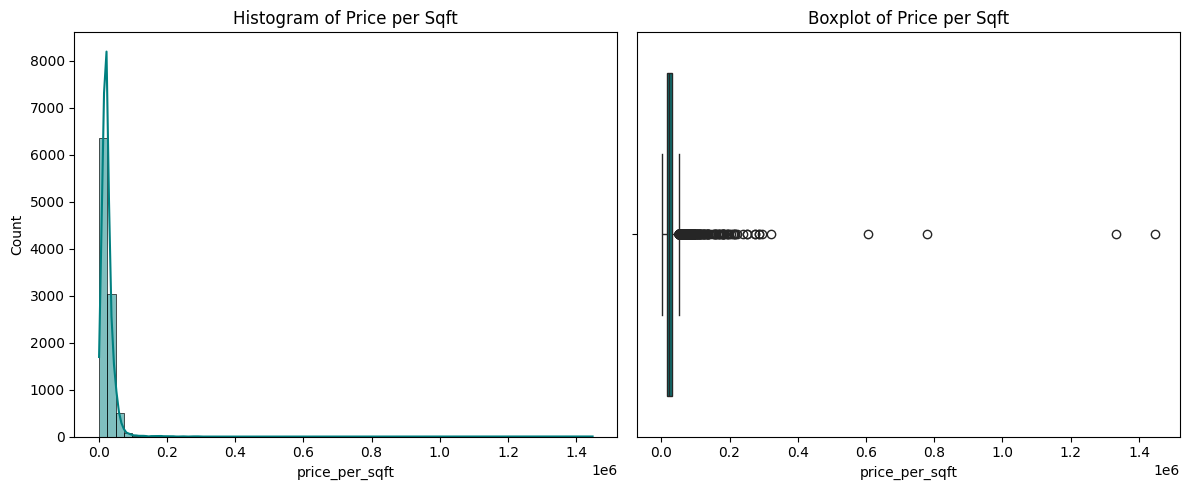

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['price_per_sqft'], bins=60, kde=True, ax=ax[0], color='teal')
ax[0].set_title("Histogram of Price per Sqft")

sns.boxplot(x=df['price_per_sqft'], ax=ax[1], color='teal')
ax[1].set_title("Boxplot of Price per Sqft")

plt.tight_layout()
plt.show()

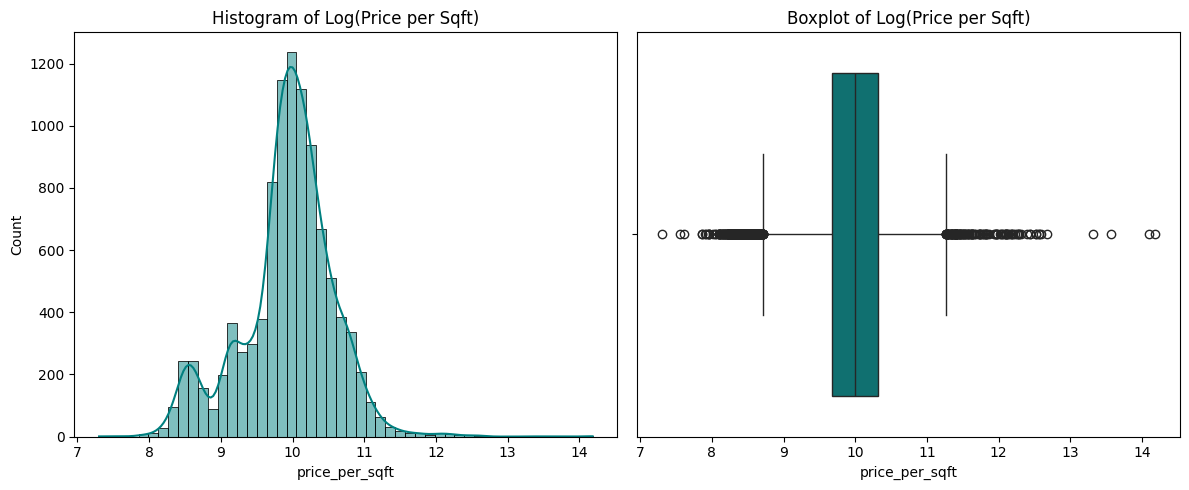

Original Skewness: 26.26
Log-Transformed Skewness: -0.29


In [38]:
import numpy as np

# Apply log1p transformation to price_per_sqft
price_per_sqft_log = np.log1p(df['price_per_sqft'])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(price_per_sqft_log, bins=50, kde=True, color='teal', ax=ax[0])
ax[0].set_title('Histogram of Log(Price per Sqft)')


sns.boxplot(x=price_per_sqft_log, color='teal', ax=ax[1])
ax[1].set_title('Boxplot of Log(Price per Sqft)')

plt.tight_layout()
plt.show()

print(f"Original Skewness: {df['price_per_sqft'].skew():.2f}")
print(f"Log-Transformed Skewness: {price_per_sqft_log.skew():.2f}")

### Price Per Sqft Analysis Insights

- **Extreme Skewness:** This column has a skewness of **26.47**, which is exceptionally high. This is driven by ultra-luxury properties where the price per sqft reaches up to **14.48 Lakhs**, while the median is just **~22,000**.
- **Market Benchmarks:** 50% of the properties fall between **15,881 and 30,309 per sqft**.
- **Outlier Impact:** The average (25,493) is significantly higher than the median (21,978), further confirming the influence of high-priced properties on the dataset.
- **Modeling Note:** Similar to the total price, this column will require a log transformation before being used in any predictive models due to its extreme distribution.

## property_score

In [39]:
basic_info(df['property_score'])

<class 'pandas.core.series.Series'>
RangeIndex: 10050 entries, 0 to 10049
Series name: property_score
Non-Null Count  Dtype
--------------  -----
10050 non-null  int64
dtypes: int64(1)
memory usage: 78.6 KB
None 

count    10050.000000
mean         2.233035
std          1.485333
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: property_score, dtype: float64 

Null:  0 

Skewness: 0.5361351881754555
 Kurtosis: -0.043450963017153565

Duplicates:  10042 



In [40]:
df['property_score'].value_counts()

,count
property_score,
2,2601
1,2266
3,2253
0,1165
4,923
5,567
6,237
7,38


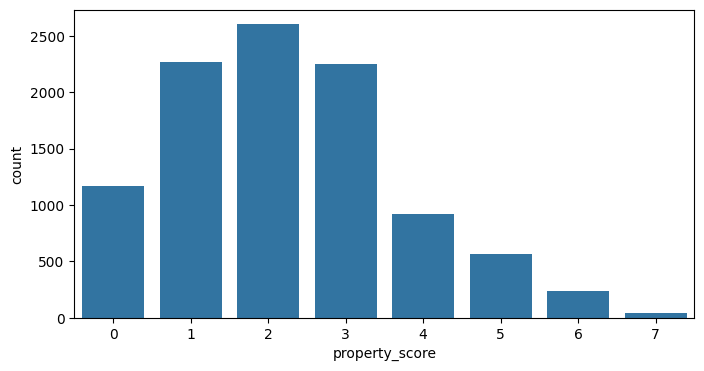

In [41]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='property_score')
plt.show()

### Property Score Analysis Insights

- **Common Ratings:** The dataset is dominated by properties with scores of **1, 2, and 3**, which account for over 70% of the listings.
- **Luxury/High-End Rarity:** Properties with a score of **6 or 7** are rare (less than 3% of the data), suggesting that top-tier amenities or high-spec properties are a niche segment.
- **Standard Quality:** The median score of **2** suggests that a baseline level of amenities is consistent across the majority of Mumbai listings.

# Categorical Univariate Analysis

In [42]:
def categorical_info(df, col):
    print(f"Total Unique Values: {df[col].nunique()}")
    print(f"Missing Values: {df[col].isna().sum()} ({df[col].isna().sum()/len(df)*100:.2f}%)")
    print(f"Most Frequent (Mode): {df[col].mode()[0]}\n")

    # Frequency table
    freq_table = df[col].value_counts().to_frame(name='Frequency')
    freq_table['Percentage (%)'] = (df[col].value_counts(normalize=True) * 100).round(2)
    display(freq_table)

    # Visualizations
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Bar Plot
    sns.countplot(data=df, x=col, ax=ax[0], palette='viridis', hue=col, legend=False)
    ax[0].set_title(f'Distribution of {col}')
    ax[0].tick_params(axis='x', rotation=45)

    # Pie Chart
    counts = df[col].value_counts()
    ax[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=0, colors=sns.color_palette('viridis', len(counts)))
    ax[1].set_title(f'Proportion of {col}')

    plt.tight_layout()
    plt.show()
    print("\n")

In [43]:
df.head()

,bhk,price,age_of_property,possesion_status,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities
0,3.0,2.05,15.0,Ready to move,Middle,Moroccan Cooperative,3.0,3.0,3.0,1.0,kaggle,Goregaon East,1862.0,1425.0,True,Semi Furnished,11009.667025,4,NaN,NaN
1,1.0,1.33,1.0,Ready to move,Lower,Rajesh White City,1.0,2.0,0.0,1.0,kaggle,Kandivali East,790.0,479.0,True,Unfurnished,16835.443038,1,NaN,NaN
2,3.0,7.30,10.0,Ready to move,Lower,Oberoi Esquire,3.0,2.0,0.0,2.0,kaggle,Goregaon East,1430.0,1330.0,True,Unfurnished,51048.951049,3,NaN,NaN
3,3.0,7.60,4.0,Ready to move,Higher,Oberoi Esquire,3.0,4.0,0.0,3.0,kaggle,Goregaon East,2195.0,1400.0,True,Semi Furnished,34624.145786,5,NaN,NaN
4,2.0,3.20,3.0,Ready to move,Lower,Ajmera Zeon,2.0,2.0,1.0,1.0,kaggle,Wadala East,960.0,860.0,True,Unfurnished,33333.333333,3,NaN,NaN


### possession_status Analysis

Total Unique Values: 1
Missing Values: 0 (0.00%)
Most Frequent (Mode): Ready to move



,Frequency,Percentage (%)
possesion_status,,
Ready to move,10050,100.0


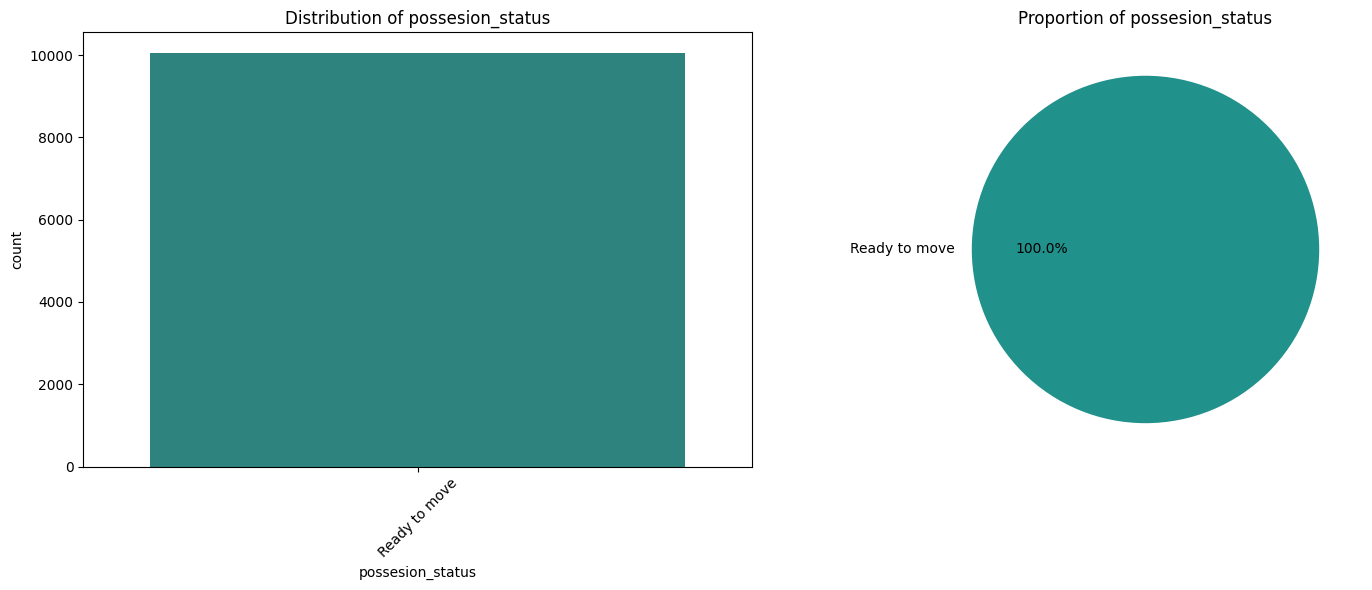

In [44]:
categorical_info(df, 'possesion_status')

In [45]:
# Since all rows are same we are dropping it
df.drop('possesion_status', inplace=True, axis=1)

## which floor

Total Unique Values: 4
Missing Values: 0 (0.00%)
Most Frequent (Mode): Middle



,Frequency,Percentage (%)
which_floor,,
Middle,3606,35.88
Higher,2622,26.09
Lower,1982,19.72
Unknown,1840,18.31


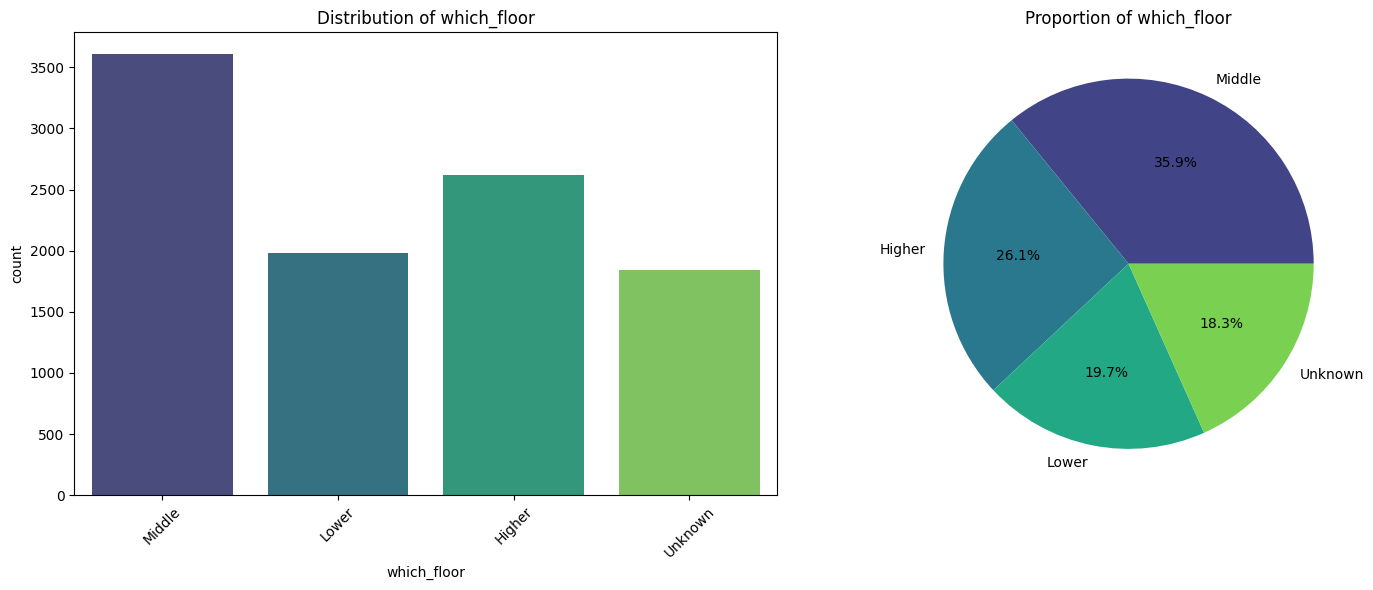

In [46]:
categorical_info(df, 'which_floor')

### which_floor Analysis Insights

- **Most Preferred:** The **Middle** floors are the most common (around 45%), indicating they are the most standard offering in the market.
- **Lower vs. Higher:** There are significantly more properties on **Lower** floors than **Higher** floors, which often correlates with the higher costs associated with elevation and views in Mumbai high-rises.
- **Data Quality:** There is a small percentage of 'Unknown' values, but the bulk of the data clearly classifies the vertical positioning of the flats.

## location

Total Unique Values: 185
Missing Values: 0 (0.00%)
Most Frequent (Mode): Mira Road East



,Frequency,Percentage (%)
location,,
Mira Road East,847,8.43
Chembur,546,5.43
Kandivali East,475,4.73
Andheri West,474,4.72
Powai,469,4.67
...,...,...
"IC Colony, Borivali West",1,0.01
"Tagore Nagar, Vikhroli East",1,0.01
"Mahavir Nagar, Kandivali West",1,0.01


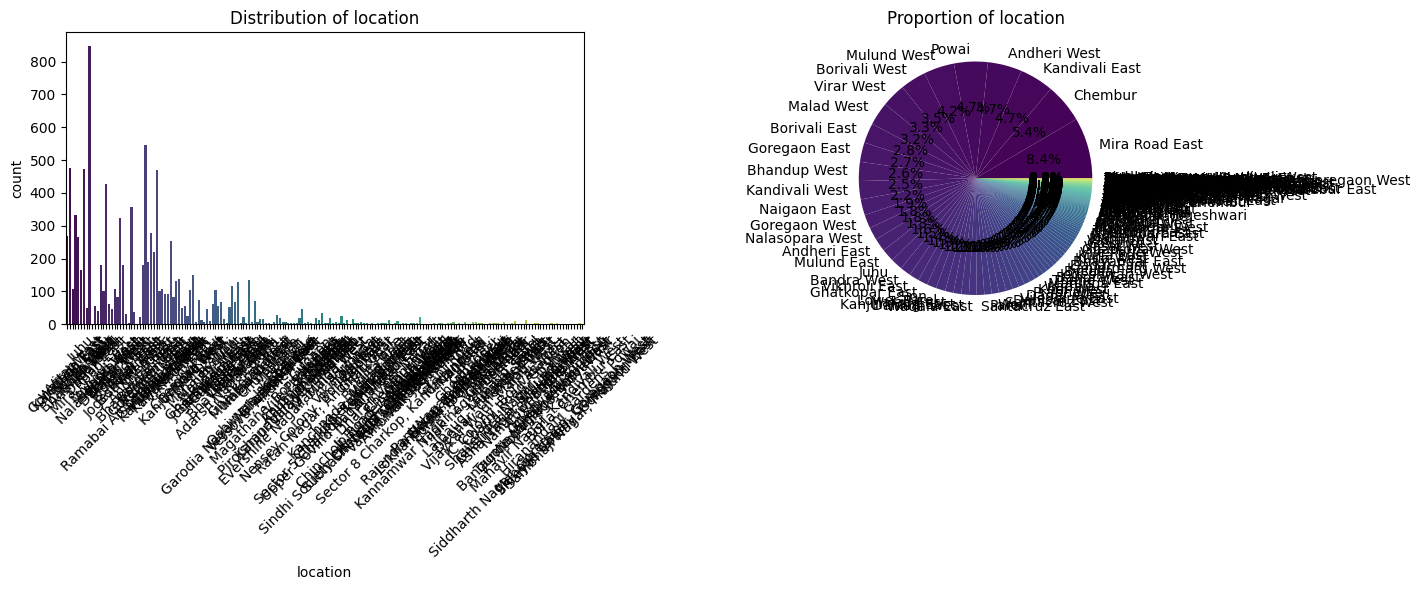

In [47]:
categorical_info(df, 'location')

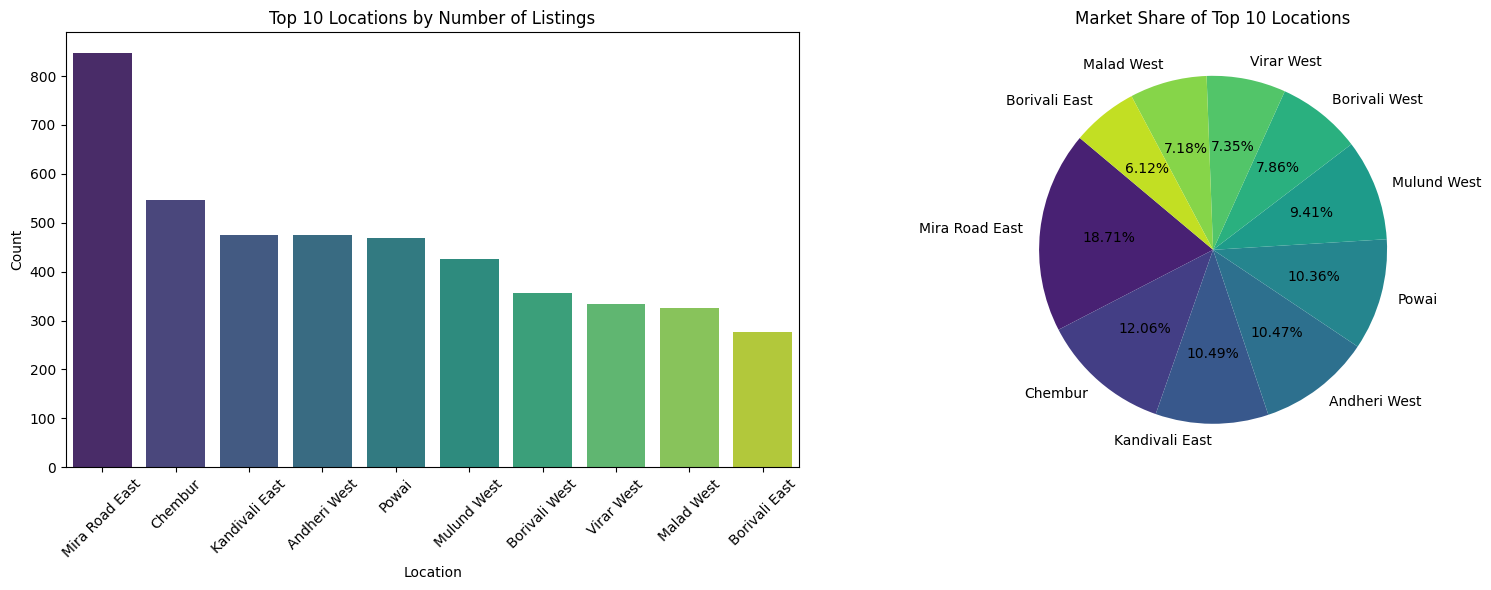

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

top_10_locations = df['location'].value_counts().head(10)

# Bar Chart on first subplot
sns.barplot(x=top_10_locations.index, y=top_10_locations.values, hue=top_10_locations.index, palette='viridis', legend=False, ax=ax[0])
ax[0].set_title('Top 10 Locations by Number of Listings')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_xlabel('Location')
ax[0].set_ylabel('Count')

# Pie Chart on second subplot
ax[1].pie(top_10_locations, labels=top_10_locations.index, autopct='%.2f%%', startangle=140, colors=sns.color_palette('viridis', 10))
ax[1].set_title('Market Share of Top 10 Locations')

plt.tight_layout()
plt.show()

### Location Analysis Insights

- **Market Concentration:** The top 10 locations account for a significant portion of the listings, with **Mira Road East** being the most frequent, followed by **Chembur** and **Andheri West**.
- **High-Activity Hubs:** Locations like Mira Road and Virar represent the affordable/mid-segment growth corridors, while Andheri and Powai represent established premium hubs.
- **Fragmentation:** With 185 unique locations, the Mumbai market is highly fragmented, though supply is concentrated in specific suburban clusters.

## furnishing

Total Unique Values: 4
Missing Values: 0 (0.00%)
Most Frequent (Mode): Semi Furnished



,Frequency,Percentage (%)
furnishing,,
Semi Furnished,3334,33.17
Unknown,2885,28.71
Unfurnished,2857,28.43
Fully Furnished,974,9.69


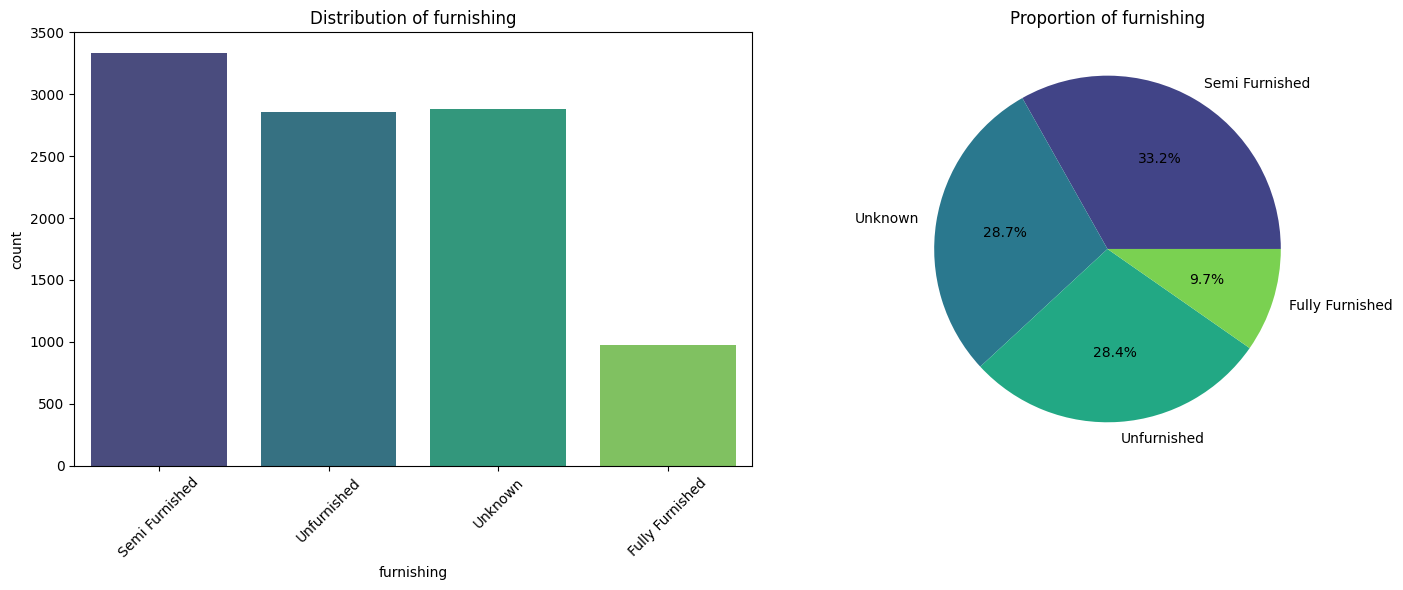

In [49]:
categorical_info(df, 'furnishing')

### Furnishing Analysis Insights

- **Market Split:** Semi-furnished (33%) and Unfurnished (29%) apartments are the most common listings.
- **Luxury/Ready Segment:** Fully furnished apartments are a smaller segment at roughly 10%, often catering to the premium or rental-ready markets.
- **Data Gap:** The 28% 'Unknown' category is significant; as noted earlier, this is primarily due to missing information from specific data sources (99acres).

## is ready to move

Total Unique Values: 2
Missing Values: 0 (0.00%)
Most Frequent (Mode): True



,Frequency,Percentage (%)
is_ready_to_move,,
True,9243,91.97
False,807,8.03


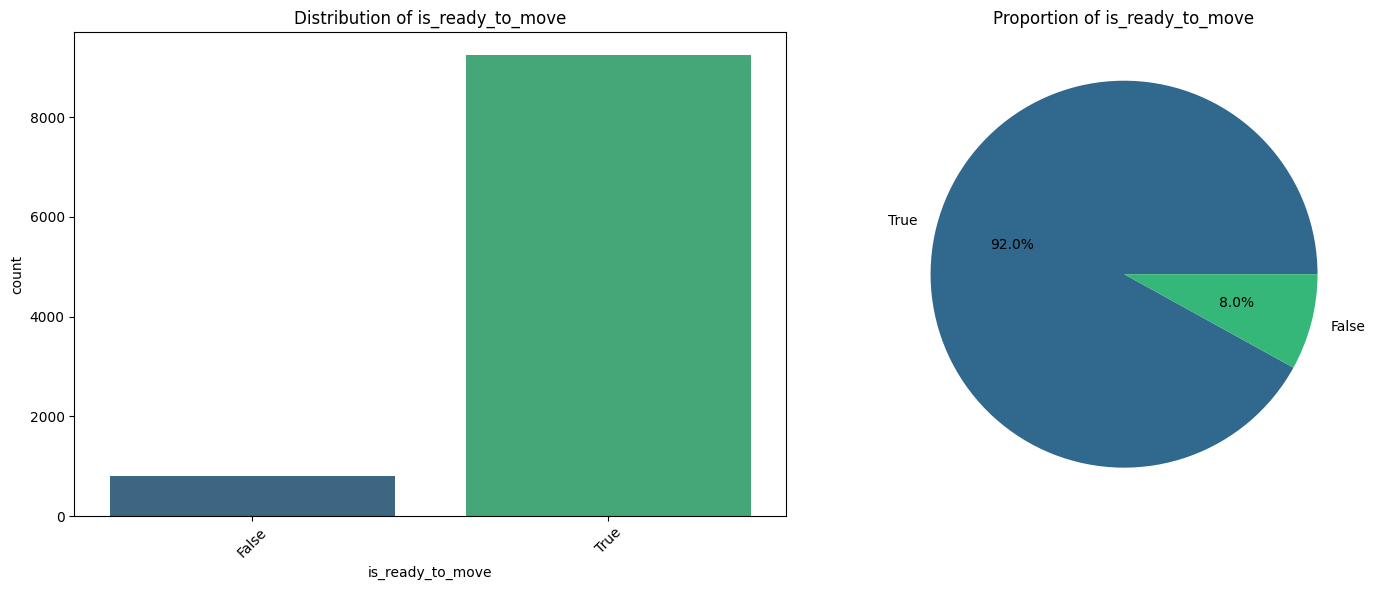

In [50]:
categorical_info(df, 'is_ready_to_move')

### Possession Status (is_ready_to_move) Insights

- **Massive Dominance:** Over **91.8%** of the properties in the dataset are 'Ready to Move', confirming that the Mumbai market listings are heavily skewed towards immediate occupancy.

## furnishing

Total Unique Values: 4
Missing Values: 0 (0.00%)
Most Frequent (Mode): Semi Furnished



,Frequency,Percentage (%)
furnishing,,
Semi Furnished,3334,33.17
Unknown,2885,28.71
Unfurnished,2857,28.43
Fully Furnished,974,9.69


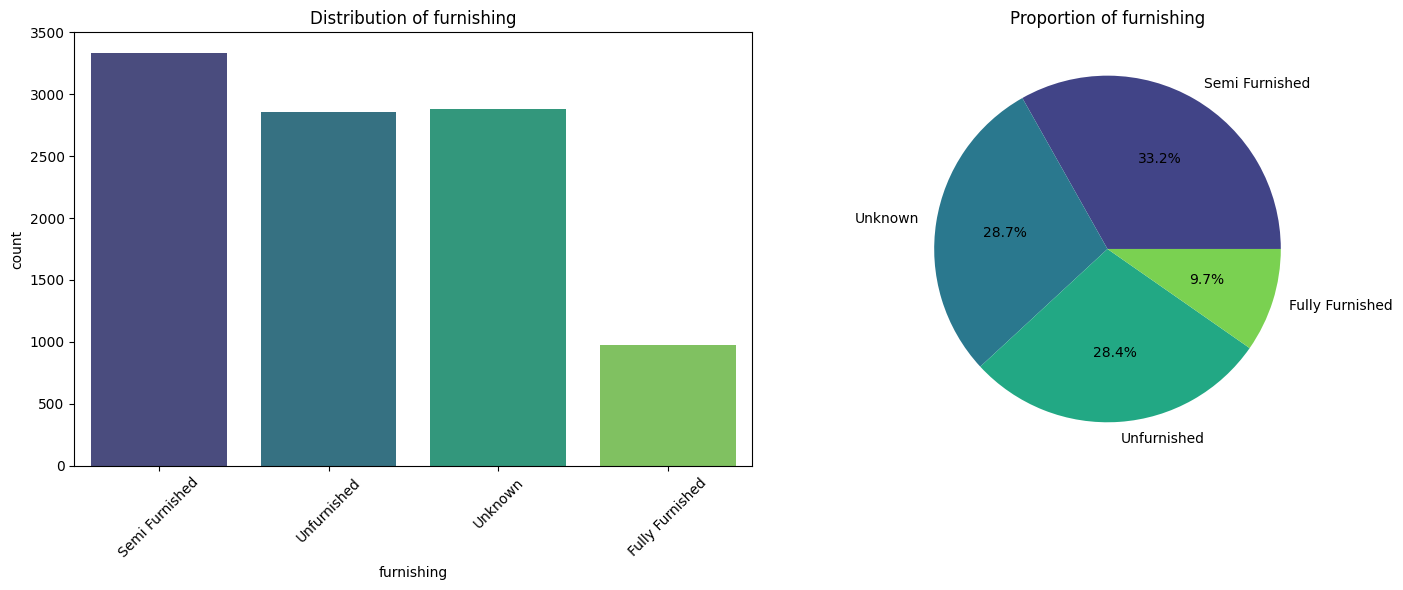

In [51]:
categorical_info(df, 'furnishing')

- **Market Dominance:** Semi-furnished (33%) and Unfurnished (29%) apartments are the most common in Mumbai

## source

In [52]:
kaggle_df = df[df['source']=="kaggle"]
acres99_df = df[df['source']=="99acres"]

print("Kaggle")
display(kaggle_df['price'].describe())
print()
print("99acres")
display(acres99_df['price'].describe())

Kaggle


,price
count,8913.000000
mean,2.979652
std,3.653640
min,0.080000
25%,1.000000
50%,1.850000
75%,3.500000
max,50.000000



99acres


,price
count,1137.000000
mean,6.629129
std,11.380368
min,0.690000
25%,1.970000
50%,3.250000
75%,6.170000
max,98.610000


# Bivariate Analysis (numeric vs numeric)



## bhk vs price

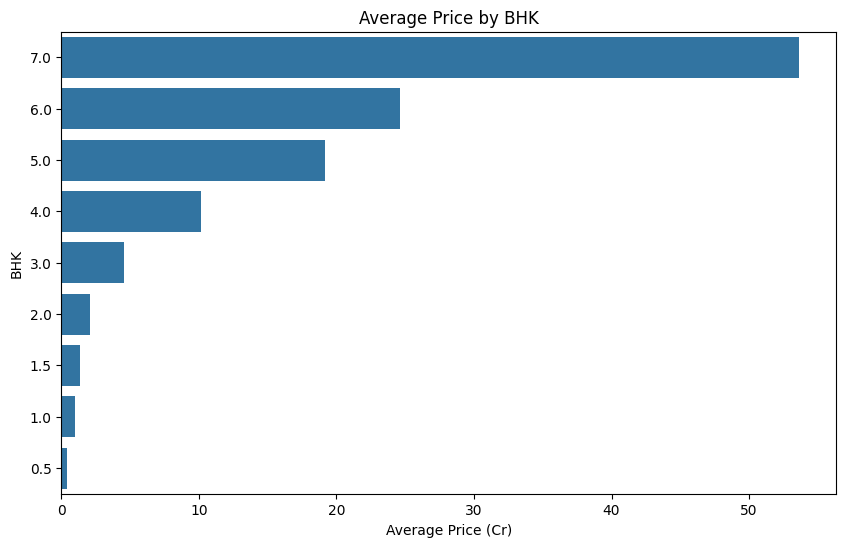

In [53]:
# Calculate order based on mean price
order = df.groupby('bhk')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='price', y='bhk', order=order, errorbar=None, orient='h')
plt.title('Average Price by BHK')
plt.xlabel('Average Price (Cr)')
plt.ylabel('BHK')
plt.show()

### BHK vs Price Insights
- **Direct Relationship:** Average property price increases significantly with the number of BHKs, as expected.
- **Luxury Jump:** There is a substantial price jump when moving from 3 BHK to 4+ BHK configurations, marking the transition into the luxury segment.

## price vs age_of_property

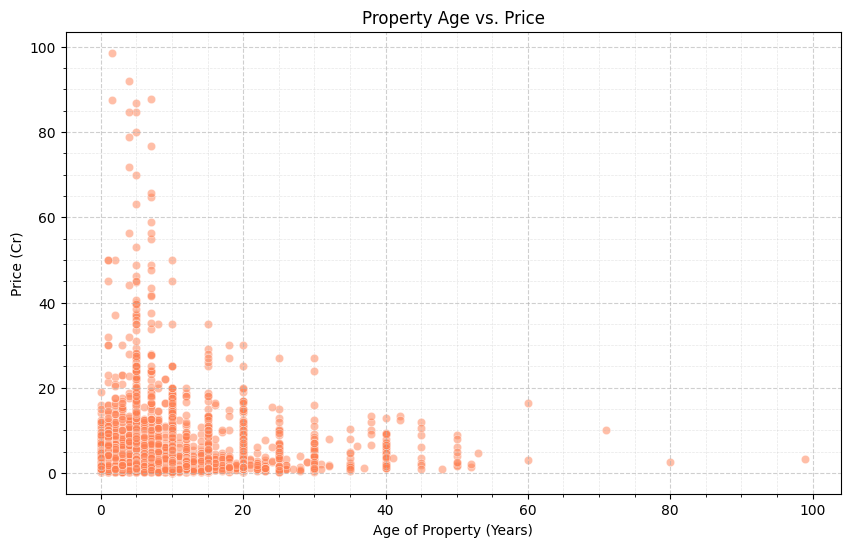

Median Price by Age Category:
age_category
New (0-5)     2.15
Mid (5-15)    1.85
Old (15+)     2.05
Name: price, dtype: float64


/tmp/ipykernel_3763/3720343456.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('age_category')['price'].median())


In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age_of_property', y='price', alpha=0.5, color='coral')
plt.title('Property Age vs. Price')
plt.xlabel('Age of Property (Years)')
plt.ylabel('Price (Cr)')
plt.minorticks_on()
plt.grid(True, which='minor', linestyle='--', alpha=0.3, linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Also checking median price for new vs old properties
df['age_category'] = pd.cut(df['age_of_property'], bins=[0, 5, 15, 100], labels=['New (0-5)', 'Mid (5-15)', 'Old (15+)'])
print("Median Price by Age Category:")
print(df.groupby('age_category')['price'].median())

### Property Age vs Price Insights
- **Non-Linear Trend:** Median prices for 'New' (0-5 years) and 'Old' (15+ years) properties are remarkably similar (2.1 Cr), while 'Mid-age' properties are slightly cheaper (1.85 Cr).
- **Resale Value:** The high price of older properties (15+ years) likely reflects the high land value and 'prime' status of established South Mumbai or premium suburban locations where these older buildings are situated.

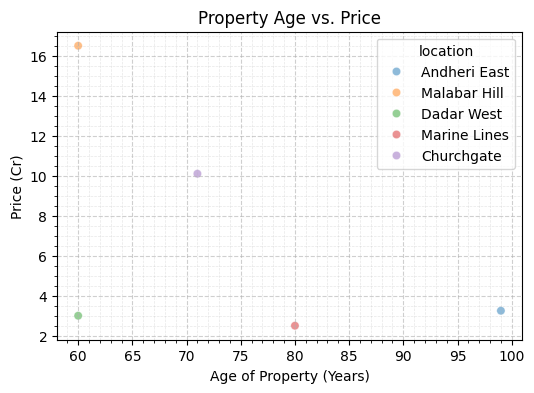

In [55]:
older_prop = df[df['age_of_property']>=60]

plt.figure(figsize=(6,4))
sns.scatterplot(data=older_prop, x='age_of_property', y='price', alpha=0.5, color='coral', hue = 'location')
plt.title('Property Age vs. Price')
plt.xlabel('Age of Property (Years)')
plt.ylabel('Price (Cr)')
plt.minorticks_on()
plt.grid(True, which='minor', linestyle='--', alpha=0.3, linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Axes: >

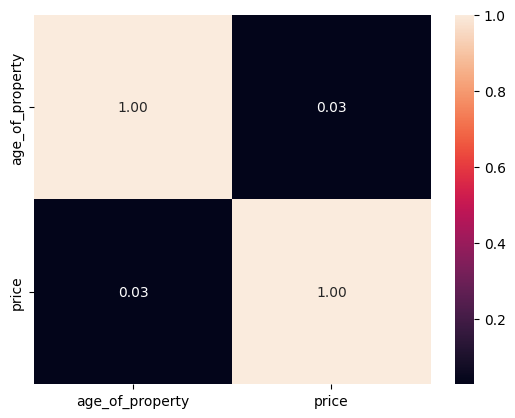

In [56]:
corr = df[['age_of_property', 'price']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", )

### Correlation Insight
- **Weak Linear Correlation (0.03):** The near-zero correlation coefficient mathematically confirms what we saw in the scatter plot: there is no simple linear relationship where 'older equals cheaper' or 'newer equals more expensive'.
- **Market Dynamics:** In Mumbai, factors like **Location** and **Land Value** often override building age, allowing heritage/well-located older properties to maintain price parity with new suburban developments.

## price vs amenities

In [57]:
def priceVSother(df, price_col, cols):

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, col in enumerate(cols):

        order = (
            df.groupby(col)[price_col]
            .median()
            .sort_index()
            .index
        )

        sns.boxplot(
            data=df,
            x=col,
            y=price_col,
            order=order,
            ax=axes[i]
        )

        axes[i].set_title(
            f'Price Distribution by {col}',
            fontsize=12
        )

        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Price (Cr)')

    plt.tight_layout()
    plt.show()

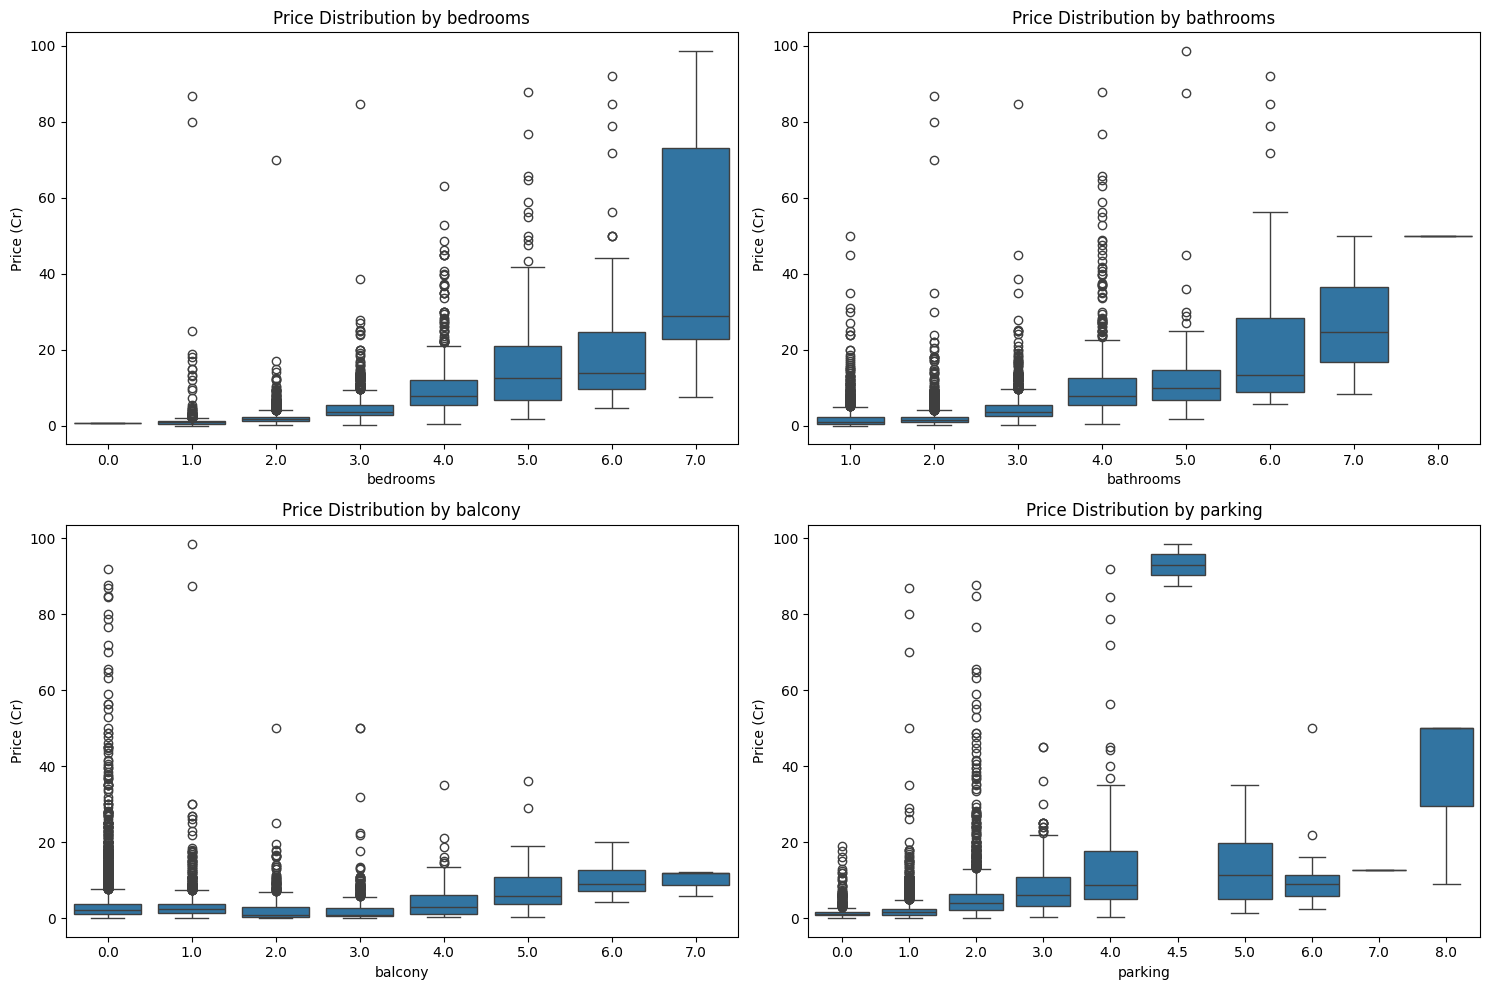

In [58]:
priceVSother(df, 'price', ['bedrooms', 'bathrooms', 'balcony', 'parking'])

### Insights: Amenities vs Price (Bivariate Analysis)

- **Consistent Appreciation:** There is a clear and consistent increase in the median price as the number of **Bedrooms** and **Bathrooms** increases. The jump from 3 to 4 bedrooms represents a major entry point into the luxury market.
- **Bathrooms as a Luxury Indicator:** The variance in price increases significantly with 4 or more bathrooms, indicating that these properties aren't just larger, but belong to high-end luxury segments with premium finishes. Premium properties with multiple bathrooms show substantial variation in pricing, reflecting differences in luxury level and location.

- **The Parking Premium:** Properties with **0 or 1 parking** spot have relatively narrow price distributions. However, properties with **2 or more parking spots** show a massive leap in median price, reflecting the high value of real estate space and the 'status' associated with multiple parking allocations in Mumbai.
- **Balcony Trends:** While 0 balconies are the most common, having **2 or 3 balconies** correlates with a significantly higher price bracket, often found in 'lifestyle' apartments or newer developments.

## Property Score vs Price
Exploring whether the quality score (amenities/features) assigned to a property has a strong correlation with its market price.

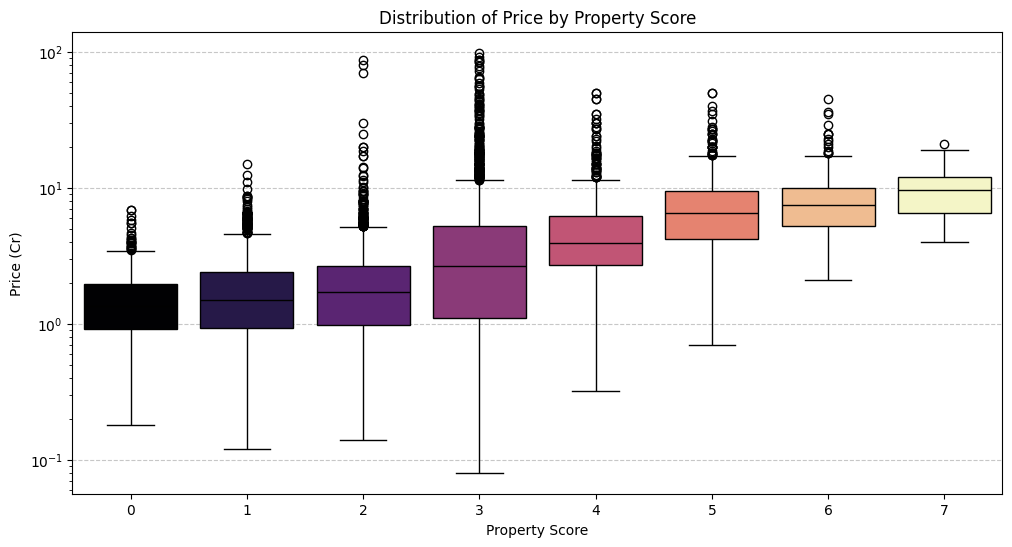

Price Statistics by Property Score:


,mean,median,count
property_score,,,
0,1.478506,1.350,1165
1,1.821408,1.490,2266
2,2.123249,1.700,2601
3,4.858877,2.650,2253
4,5.248277,3.900,923
5,7.898042,6.500,567
6,8.768228,7.500,237
7,9.872368,9.625,38


In [59]:
plt.figure(figsize=(12, 6))

# Boxplot to see distribution and median price per score
sns.boxplot(data=df, x='property_score', y='price', palette='magma', hue='property_score', legend=False)
plt.title('Distribution of Price by Property Score')
plt.xlabel('Property Score')
plt.ylabel('Price (Cr)')
plt.yscale('log')  # Using log scale due to extreme price outliers
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Average price calculation
score_price_stats = df.groupby('property_score')['price'].agg(['mean', 'median', 'count'])
print("Price Statistics by Property Score:")
display(score_price_stats)

### Insights: Property Score vs Price

- **Direct Value Correlation:** There is a consistent upward trend where higher **Property Scores** correlate with significantly higher median prices, proving that the quality and quantity of amenities are primary price drivers.
- **Luxury Thresholds:** Scores of **5 and above** represent the clear luxury segment, where median prices jump to over **6.5 Cr**.
- **Market Tiering:** The significant price variance at higher scores (6-7) suggests that for top-rated properties, factors like brand name and exclusive location add a further premium beyond just the physical amenities.

## price vs buildup_area_sqft

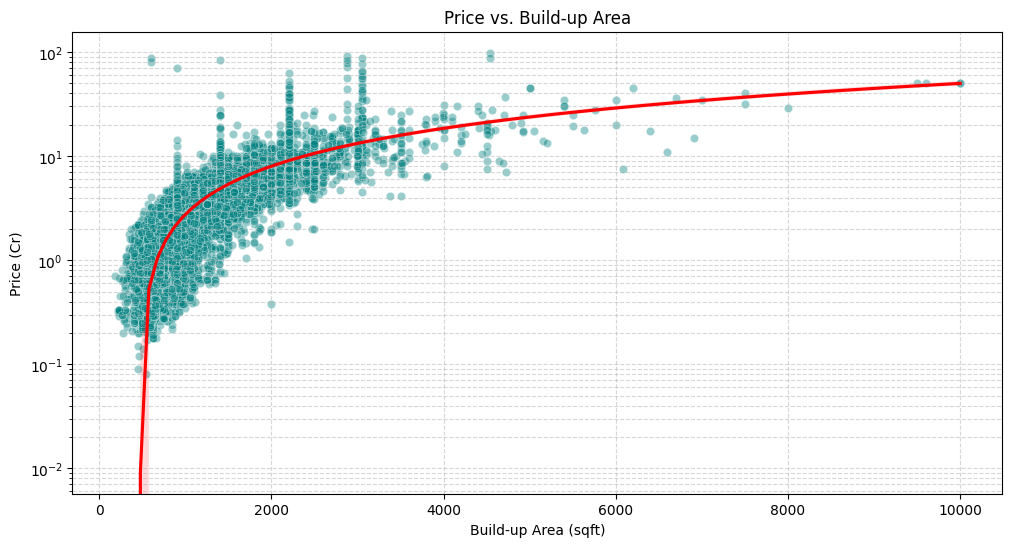

Correlation between Build-up Area and Price: 0.68


In [60]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='buildup_area_sqft', y='price', alpha=0.4, color='teal')
sns.regplot(data=df, x='buildup_area_sqft', y='price', scatter=False, color='red')
plt.title('Price vs. Build-up Area')
plt.xlabel('Build-up Area (sqft)')
plt.ylabel('Price (Cr)')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

print(f"Correlation between Build-up Area and Price: {df['buildup_area_sqft'].corr(df['price']):.2f}")

In [61]:
bins = [0, 2000, 6000, 8000, 10000]
labels = ['0-2000', '2000-6000', '6000-8000', '8000-10000']

df['area_bins'] = pd.cut(df['buildup_area_sqft'], bins=bins, labels=labels)

area_price_analysis = df.groupby('area_bins', observed=False)['price'].agg(['count', 'mean']).rename(columns={'mean': 'avg_price_cr'})

display(area_price_analysis)
df.drop(columns=['area_bins'], inplace=True)

,count,avg_price_cr
area_bins,,
0-2000,9163,2.437821
2000-6000,873,12.931512
6000-8000,10,26.800000
8000-10000,4,50.000000


### Insights: Price vs. Build-up Area

- **Strong Positive Correlation:** There is a clear linear trend showing that as the build-up area increases, the price rises significantly (Correlation: 0.68).
- **Density in Mid-Segment:** The densest cluster of properties lies between **500 and 1,500 sqft**, corresponding to the 1.0 to 5.0 Cr price range.
- **Luxury Spread:** Above 2,000 sqft, the price variance increases drastically, where similar-sized properties can vary by tens of crores depending on luxury features and location.

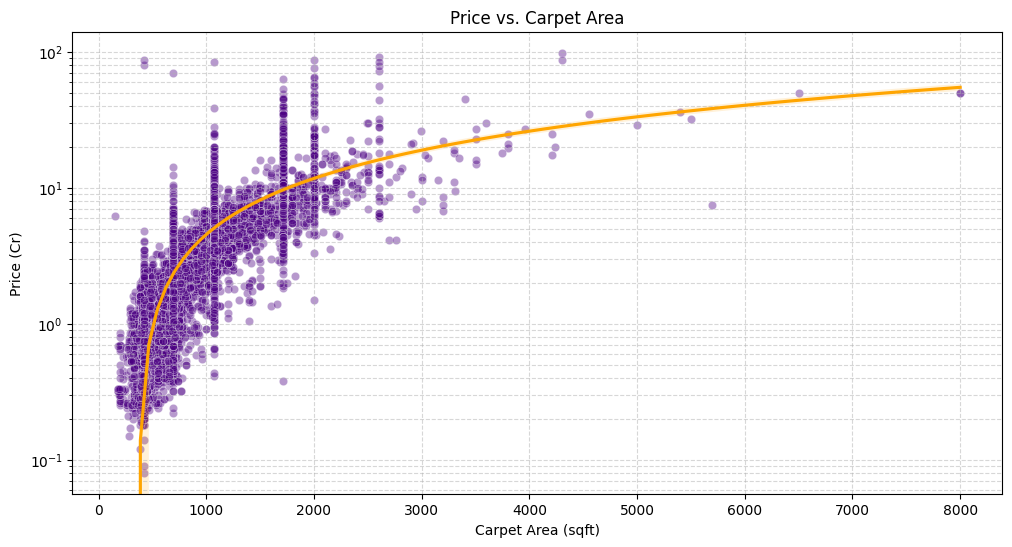

Correlation between Carpet Area and Price: 0.66


In [62]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='carpet_area_sqft', y='price', alpha=0.4, color='indigo')
sns.regplot(data=df, x='carpet_area_sqft', y='price', scatter=False, color='orange')
plt.title('Price vs. Carpet Area')
plt.xlabel('Carpet Area (sqft)')
plt.ylabel('Price (Cr)')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

print(f"Correlation between Carpet Area and Price: {df['carpet_area_sqft'].corr(df['price']):.2f}")

### Insights: Price vs. Carpet Area

- **Primary Price Driver:** Carpet area shows a tight relationship with price (Correlation: 0.66), reinforcing that buyers in Mumbai primarily pay for the actual usable space.
- **Outlier Influence:** The ultra-luxury properties (90+ Cr) often have massive carpet areas (>4000 sqft), acting as extreme anchor points for the top end of the market.
- **Consistency:** The consistent slope indicates that square footage is a reliable predictor for the base price of a property before adding premiums for amenities or floor height.

# Bivariate Analysis (numerical vs categorical)


## price vs location

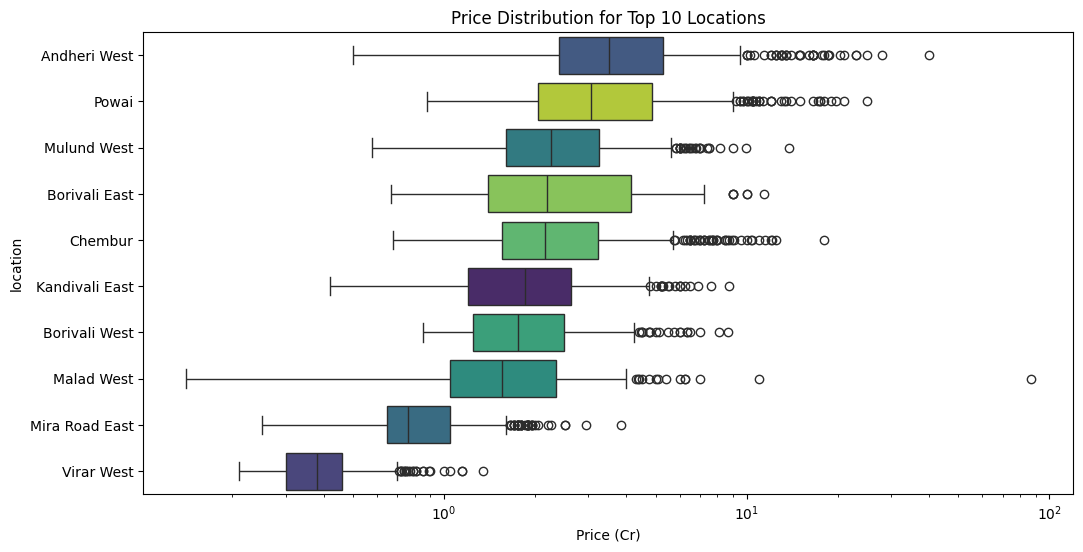

In [63]:
top_10 = df['location'].value_counts().head(10).index
df_top = df[df['location'].isin(top_10)]

plt.figure(figsize=(12, 6))
order = df_top.groupby('location')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top, x='price', y='location', order=order, palette='viridis', hue='location', legend=False)
plt.title('Price Distribution for Top 10 Locations')
plt.xlabel('Price (Cr)')
plt.xscale('log')
plt.show()

### Insights: Location vs Price

- **Location Premium:** Prices vary significantly by location. Areas like **Andheri West** and **Powai** show higher median prices compared to growth corridors like **Mira Road East** or **Virar West**.
- **Market Segment Distribution:** The narrow distribution in Mira Road vs the wide spread in Andheri indicates that some locations are more socio-economically diverse (mix of luxury and mid-segment) than others.

## price vs furnishing

1.   List item
2.   List item



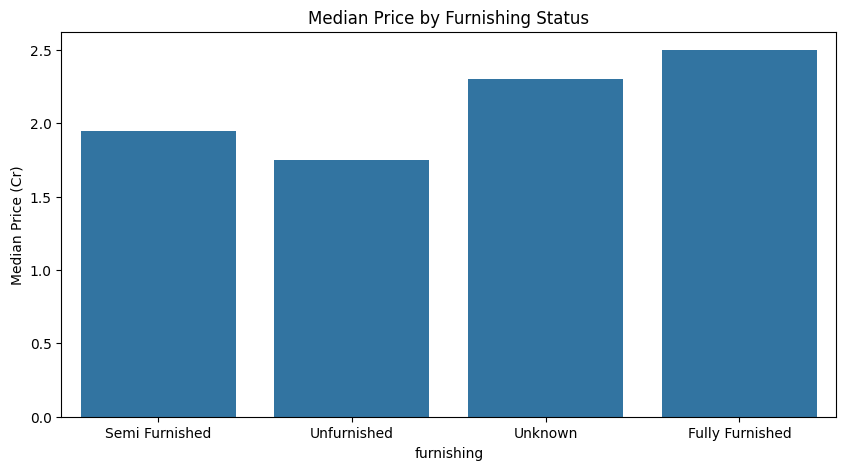

In [64]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='furnishing', y='price', estimator='median', errorbar=None, legend=False)
plt.title('Median Price by Furnishing Status')
plt.ylabel('Median Price (Cr)')
plt.show()

- **Furnishing Impact:** Fully furnished properties command a higher median price (~2.5 Cr) compared to semi-furnished or unfurnished units, reflecting the added value of move-in readiness and interior investment.

## price vs floor

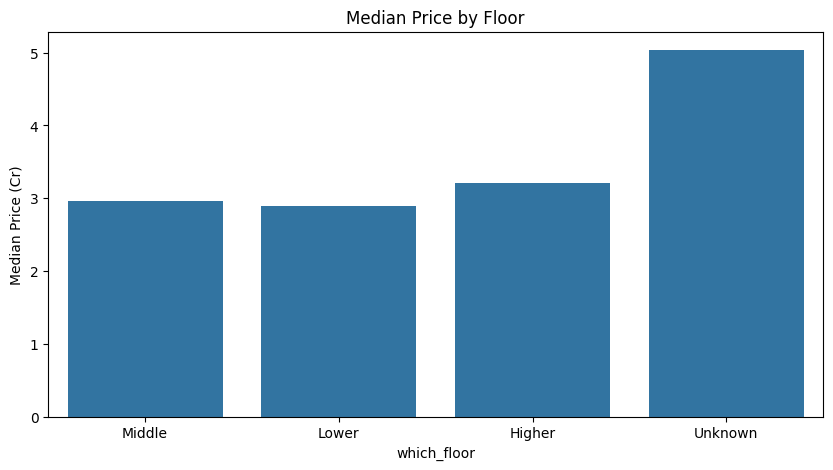

In [65]:
plt.figure(figsize=(10, 5))
sns.barplot(df, x='which_floor', y='price', errorbar=None, legend=False)
plt.title('Median Price by Floor')
plt.ylabel('Median Price (Cr)')
plt.show()


### Insights: Price & Floor Level

- Unknown floor properties have the highest median price (\~5 Cr), significantly higher than all other floor categories.
Higher-floor properties (\~3.2 Cr median) command a slight premium over lower and middle floors.

- Middle and lower floors have very similar median prices (~2.9–3.0 Cr), indicating floor level has limited impact within these categories.

- The price difference between higher floors and lower/middle floors is modest, suggesting location, size, and amenities may influence price more than floor position.

In [66]:
df.head()

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category
0,3.0,2.05,15.0,Middle,Moroccan Cooperative,3.0,3.0,3.0,1.0,kaggle,Goregaon East,1862.0,1425.0,True,Semi Furnished,11009.667025,4,NaN,NaN,Mid (5-15)
1,1.0,1.33,1.0,Lower,Rajesh White City,1.0,2.0,0.0,1.0,kaggle,Kandivali East,790.0,479.0,True,Unfurnished,16835.443038,1,NaN,NaN,New (0-5)
2,3.0,7.30,10.0,Lower,Oberoi Esquire,3.0,2.0,0.0,2.0,kaggle,Goregaon East,1430.0,1330.0,True,Unfurnished,51048.951049,3,NaN,NaN,Mid (5-15)
3,3.0,7.60,4.0,Higher,Oberoi Esquire,3.0,4.0,0.0,3.0,kaggle,Goregaon East,2195.0,1400.0,True,Semi Furnished,34624.145786,5,NaN,NaN,New (0-5)
4,2.0,3.20,3.0,Lower,Ajmera Zeon,2.0,2.0,1.0,1.0,kaggle,Wadala East,960.0,860.0,True,Unfurnished,33333.333333,3,NaN,NaN,New (0-5)


## price vs source

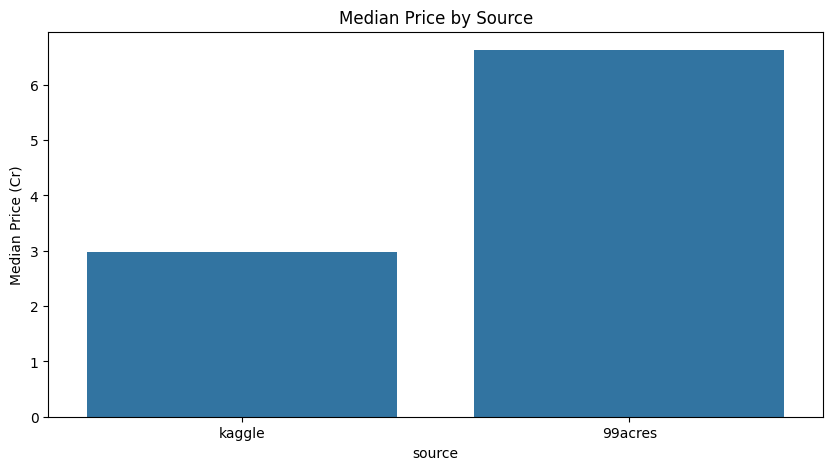

In [67]:
plt.figure(figsize=(10, 5))
sns.barplot(df, x='source', y='price', errorbar=None, legend=False)
plt.title('Median Price by Source')
plt.ylabel('Median Price (Cr)')
plt.show()


In [68]:
df.groupby('source')['location'].nunique()

,location
source,
99acres,139
kaggle,101


In [69]:
df.groupby('source')['location'].value_counts()

source   location      
99acres  Andheri West      46
         Ghatkopar East    45
         Mulund West       44
         Malad West        39
         Vikhroli East     39
                           ..
kaggle   Makane Kapase      1
         Mira Road West     1
         Nagpada            1
         Umerkhadi          1
         Uttan              1
Name: count, Length: 240, dtype: int64

In [70]:
df.groupby('source')['location'].value_counts().loc["kaggle"].head(10)

,count
location,
Mira Road East,847
Chembur,510
Kandivali East,456
Powai,453
Andheri West,428
Mulund West,382
Virar West,333
Borivali West,322
Malad West,286


<Axes: xlabel='source', ylabel='price'>

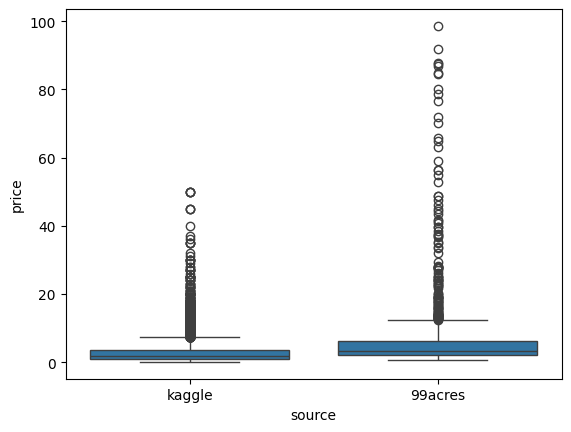

In [71]:
sns.boxplot(
    data=df,
    x='source',
    y='price'
)

In [72]:
df.groupby('source')['price_per_sqft'].median()

,price_per_sqft
source,
99acres,28642.857143
kaggle,21111.111111


In [73]:
(28642-21111)*100

753100

In [74]:
medians = df.groupby('source')['price_per_sqft'].median()
acres_median = medians['99acres']
kaggle_median = medians['kaggle']

percentage_diff = ((acres_median - kaggle_median) / kaggle_median) * 100

print(f"Median Price per Sqft (99acres): {acres_median:,.2f}")
print(f"Median Price per Sqft (Kaggle): {kaggle_median:,.2f}")
print(f"Percentage Difference: {percentage_diff:.2f}%")

Median Price per Sqft (99acres): 28,642.86
Median Price per Sqft (Kaggle): 21,111.11
Percentage Difference: 35.68%


- The merged dataset contains properties collected from different sources and time periods. To account for potential market appreciation and source-specific differences, a source feature was retained and its impact on model performance was evaluated experimentally.

In [75]:
df.head()

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category
0,3.0,2.05,15.0,Middle,Moroccan Cooperative,3.0,3.0,3.0,1.0,kaggle,Goregaon East,1862.0,1425.0,True,Semi Furnished,11009.667025,4,NaN,NaN,Mid (5-15)
1,1.0,1.33,1.0,Lower,Rajesh White City,1.0,2.0,0.0,1.0,kaggle,Kandivali East,790.0,479.0,True,Unfurnished,16835.443038,1,NaN,NaN,New (0-5)
2,3.0,7.30,10.0,Lower,Oberoi Esquire,3.0,2.0,0.0,2.0,kaggle,Goregaon East,1430.0,1330.0,True,Unfurnished,51048.951049,3,NaN,NaN,Mid (5-15)
3,3.0,7.60,4.0,Higher,Oberoi Esquire,3.0,4.0,0.0,3.0,kaggle,Goregaon East,2195.0,1400.0,True,Semi Furnished,34624.145786,5,NaN,NaN,New (0-5)
4,2.0,3.20,3.0,Lower,Ajmera Zeon,2.0,2.0,1.0,1.0,kaggle,Wadala East,960.0,860.0,True,Unfurnished,33333.333333,3,NaN,NaN,New (0-5)


In [76]:
df.groupby('is_ready_to_move')['price'].agg(['mean', 'median'])

,mean,median
is_ready_to_move,,
False,2.323309,1.60
True,3.485887,2.02


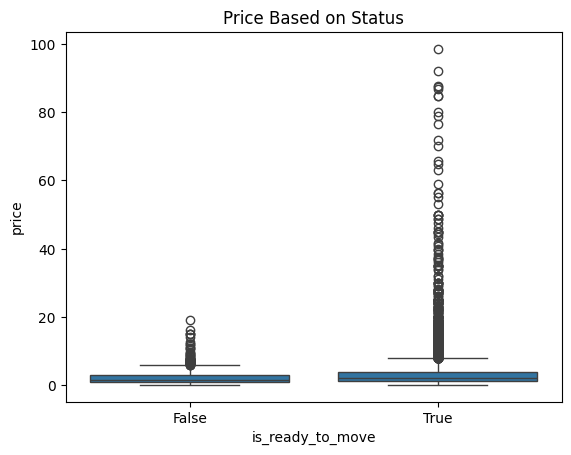

In [77]:
sns.boxplot(df, x='is_ready_to_move', y='price')
plt.title("Price Based on Status")
plt.show()

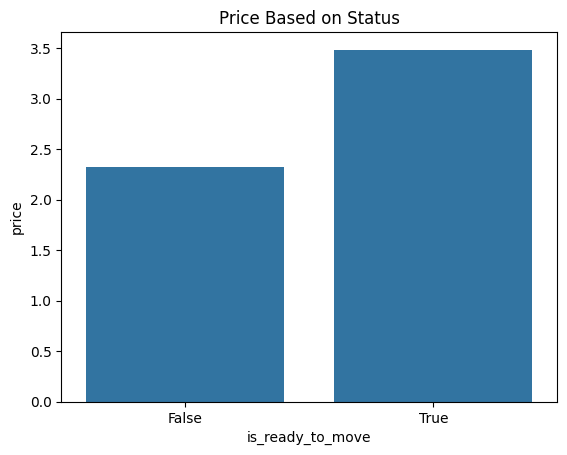

In [78]:
sns.barplot(df, x='is_ready_to_move', y='price', errorbar=None)
plt.title("Price Based on Status")
plt.show()

### Insights: is_ready_to_move vs Price

- **Ready-to-Move Premium:** Properties that are 'Ready to Move' command a significantly higher median price (**~2.02 Cr**) compared to under-construction properties (**~1.60 Cr**).
- **Value Gap:** On average, ready properties are priced about **50% higher** (3.48 Cr vs 2.32 Cr mean), which likely reflects the reduction in risk and the immediate utility value for buyers.
- **Luxury Availability:** The boxplot indicates that almost all extreme luxury outliers (priced above 20 Cr) are in the 'Ready to Move' category, suggesting that the ultra-high-end market in Mumbai prioritizes completed inventory.

## bhk vs furnishing

<Axes: xlabel='furnishing'>

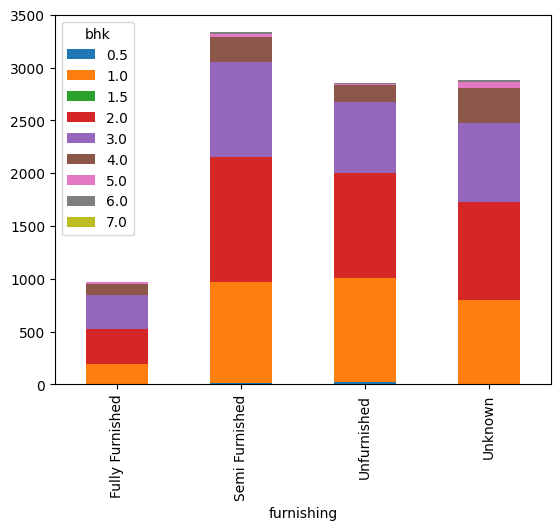

In [79]:
pd.crosstab(df['furnishing'], df['bhk']).plot(kind='bar', stacked=True)

<Axes: xlabel='furnishing', ylabel='bhk'>

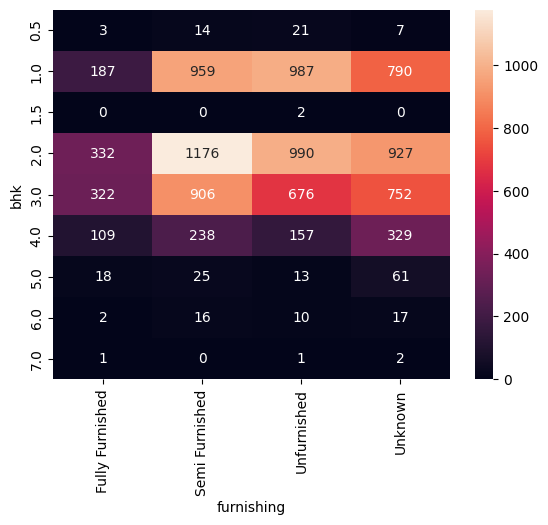

In [80]:
ct = pd.crosstab(df["bhk"], df["furnishing"])
sns.heatmap(ct, annot=True, fmt="d")

### Insights: BHK vs Furnishing

- **Inventory Dominance:** The 1 BHK and 2 BHK segments show the highest concentration of listings across all furnishing types, particularly in the **Unfurnished** and **Semi-Furnished** categories.
- **Furnishing Trends:** As the BHK count increases (4+ BHK), there is a noticeable rise in the proportion of **'Unknown'** furnishing status, likely due to these high-end listings being sourced from 99acres (which lacks furnishing data).
- **Ready-to-Use 1 BHKs:** There is a strong presence of **Semi-Furnished 1 BHKs** (959 units), suggesting a high market supply for small, move-in-ready rental or entry-level homes.

## bhk vs buildup_area

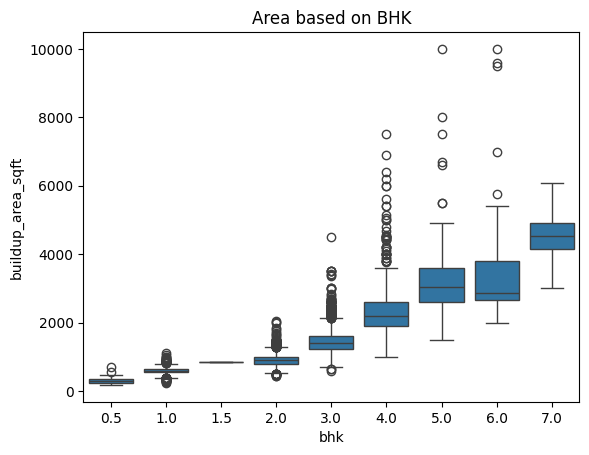

In [81]:
sns.boxplot(df, x='bhk', y='buildup_area_sqft')
plt.title("Area based on BHK")
plt.show()

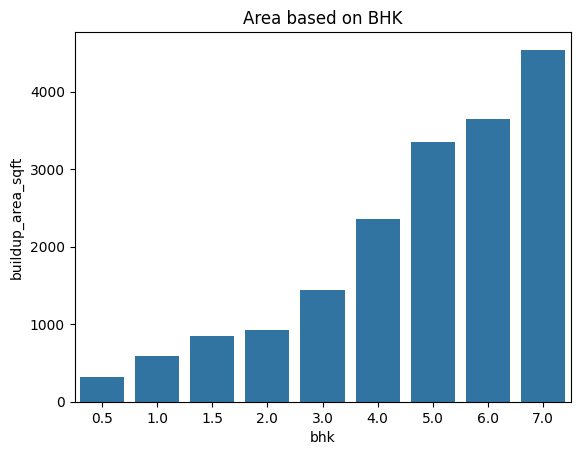

In [82]:
sns.barplot(df, x='bhk', y='buildup_area_sqft', errorbar=None)
plt.title("Area based on BHK")
plt.show()

### Insights: BHK vs Build-up Area

- **Expected Growth:** As expected, the average build-up area increases linearly with the number of bedrooms (BHK), ranging from ~600 sqft for 1 BHKs to over 4,500 sqft for 7 BHKs.
- **Variance & Overlap:** The boxplot reveals significant overlap between categories. For instance, some large **2 BHKs** (reaching up to 2,050 sqft) are more spacious than many **3 BHKs**, indicating a market for 'spacious mid-segment' vs 'compact luxury'.
- **Luxury Spread:** In the **4+ BHK** segments, the variance in area explodes. This suggests that in the high-end market, buyers are paying for significantly different floor plans even if the bedroom count remains the same.
- **Efficiency Limits:** The minimum area for a 3 BHK (\~600 sqft) vs a 1 BHK (~240 sqft) highlights how aggressively space is optimized in Mumbai's compact housing segments.

## bhk vs location

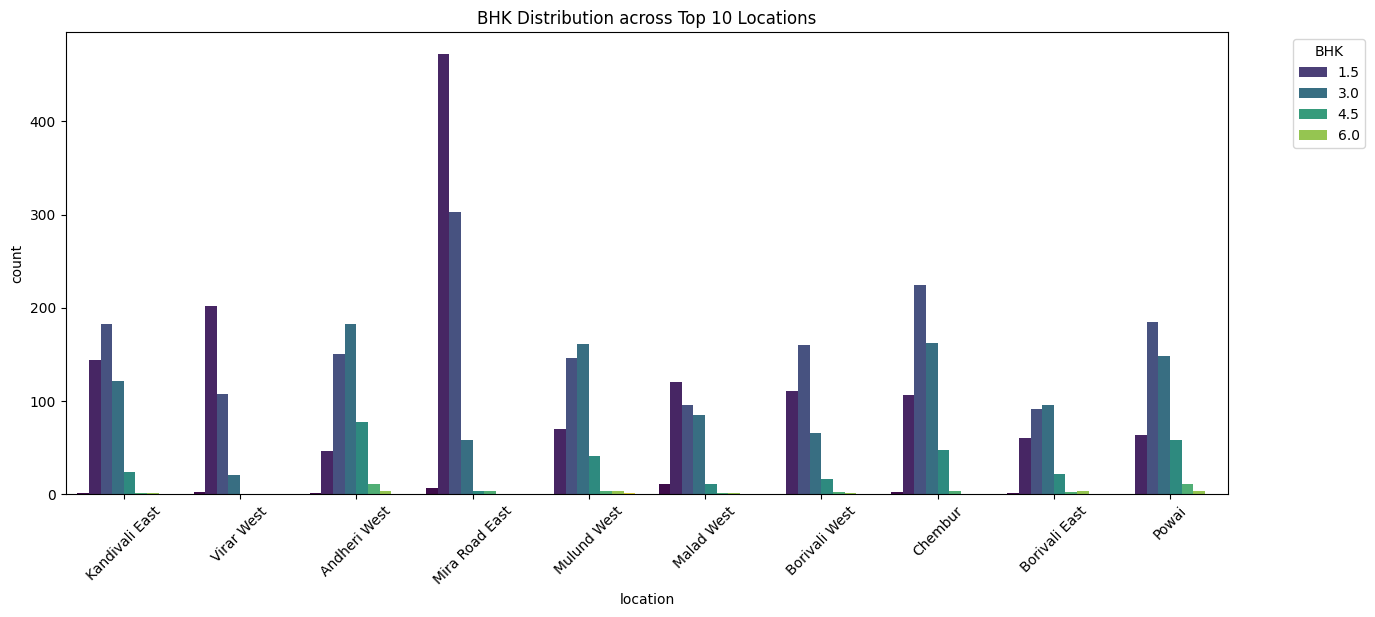

In [83]:
top_10_locs = df['location'].value_counts().head(10).index
df_loc_bhk = df[df['location'].isin(top_10_locs)]

plt.figure(figsize=(15, 6))
sns.countplot(data=df_loc_bhk, x='location', hue='bhk', palette='viridis')
plt.title('BHK Distribution across Top 10 Locations')
plt.xticks(rotation=45)
plt.legend(title='BHK', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<Axes: xlabel='bhk', ylabel='location'>

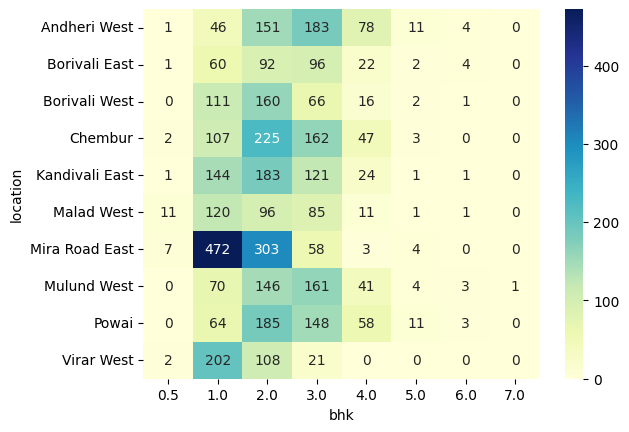

In [84]:
pivot = pd.crosstab(df_loc_bhk['location'], df_loc_bhk['bhk'])

sns.heatmap(
    pivot,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

### Insights: BHK vs Location

- **Affordable Hubs:** Locations like **Mira Road East** and **Virar West** are dominated by 1 and 2 BHKs, catering primarily to the entry-level and mid-segment markets.
- **Premium Diversity:** **Andheri West** and **Powai** show a more balanced distribution with a significant presence of 3 BHKs, reflecting their status as upscale residential hubs.
- **Space Optimization:** **Chembur** and **Kandivali** show a massive skew toward 2 BHK units, indicating they are the 'sweet spot' for suburban family housing.

## price_per_sqft vs location

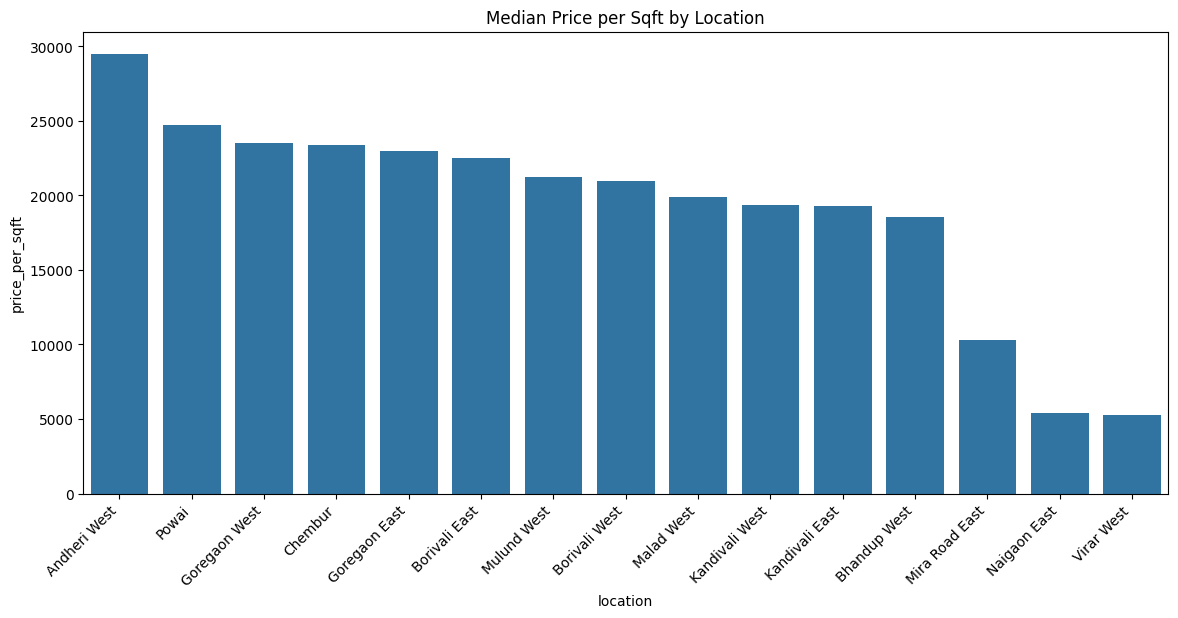

In [85]:
top_15 = df['location'].value_counts().head(15).index
df_top = df[df['location'].isin(top_15)]

order = df_top.groupby('location')['price_per_sqft'].median().sort_values(ascending=False).index
plt.figure(figsize=(14,6))
sns.barplot(data=df_top, x='location', y='price_per_sqft', order=order, estimator='median', errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title('Median Price per Sqft by Location')
plt.show()

### Insights: Price per Sqft vs Location

- **Premium Zones:** Locations like **Andheri West**, **Powai**, and **Borivali East** command the highest rates (median ~>25k per sqft), reflecting superior infrastructure and central connectivity.
- **Value Corridors:** **Mira Road East** and **Virar West** offer the lowest entry points (median <15k per sqft), making them the primary hubs for affordable housing.
- **Regional Disparity:** There is a nearly **2.5x price difference** between the most and least expensive top-tier locations, highlighting the extreme impact of micro-markets on Mumbai real estate value.

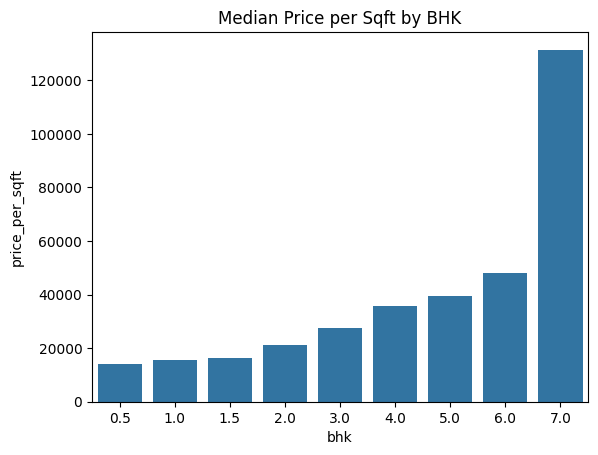

In [86]:
sns.barplot(data=df, x='bhk', y='price_per_sqft', estimator='median', errorbar=None)
plt.title('Median Price per Sqft by BHK')
plt.show()

### Insights: Price per Sqft vs BHK

- **Efficiency Premium:** The median price per sqft remains relatively flat between 1 and 3 BHKs, as these cater to the volume-driven mid-market.
- **Luxury Scalability:** A sharp uptick in rate-per-sqft is visible from **4 BHK onwards**, confirming that buyers pay a premium not just for more space, but for a higher *quality* of space and exclusivity.

# Multivariate Analysis

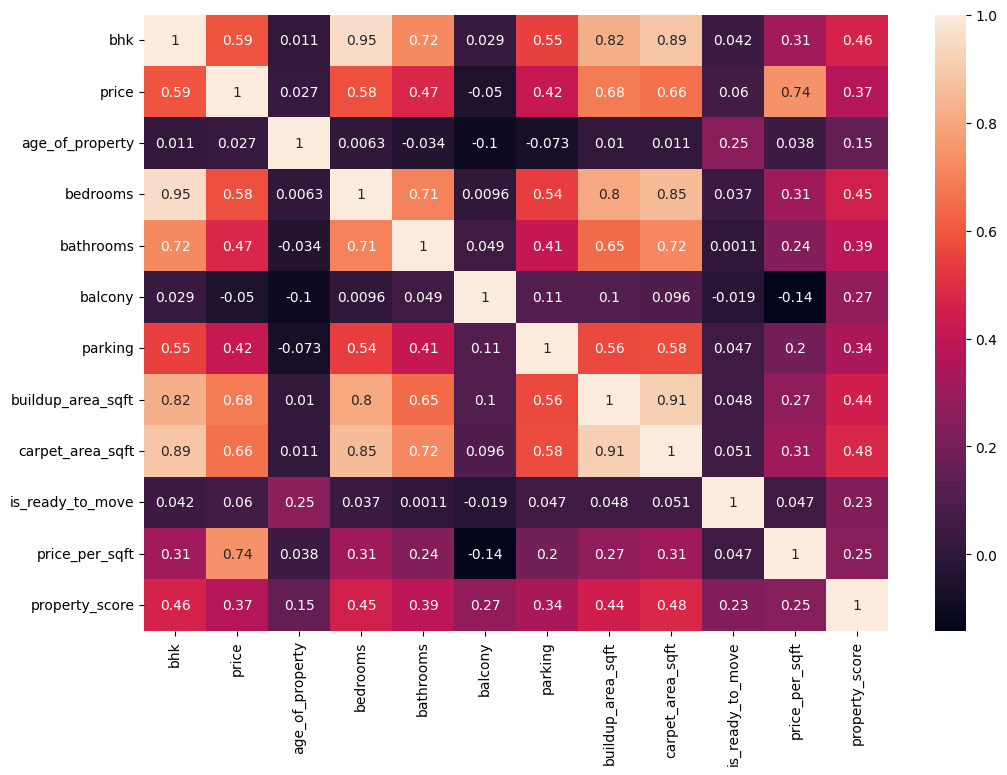

In [87]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)
plt.show()

### Insights: Correlation Heatmap

*   **Primary Drivers:** **Build-up Area (0.68)** and **BHK (0.59)** show the strongest positive correlation with Price, confirming that size and configuration are the dominant valuation factors.
*   **High Multicollinearity:** There is an extremely high correlation (~0.95) between **BHK** and **Bedrooms**, and significant correlation with **Bathrooms**. For future modeling, we may need to drop redundant features to avoid multicollinearity issues.
*   **Area vs. Price per Sqft:** Interestingly, **Price per Sqft (0.26)** has a lower correlation with total Price than absolute Area does, suggesting that total 'ticket size' is driven more by the amount of space than just the premium rate of the location.

## price vs area by bhk

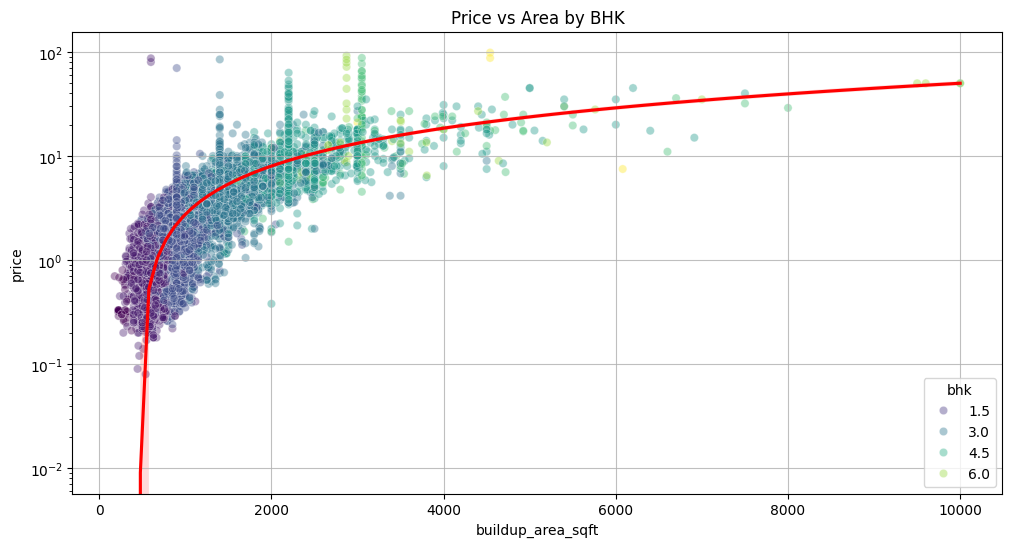

In [93]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='buildup_area_sqft', y='price', hue='bhk', alpha=0.4, palette='viridis')
sns.regplot(df, x='buildup_area_sqft', y='price', scatter=False, color = 'red')
plt.yscale('log')
plt.grid(alpha=0.8)
plt.title('Price vs Area by BHK')
plt.show()

### Insights: Price vs Area by BHK

*   **Category Overlap:** Significant overlap exists between 2 and 3 BHKs; many 2 BHKs have larger areas than standard 3 BHKs, distinguishing 'compact luxury' from 'spacious mid-segment'.
*   **Volume Dominance:** 1-3 BHK units form the dense core of the market, with 1 BHKs showing the tightest clustering in area and price.
*   **Luxury Divergence:** From 4 BHK onwards, the relationship between area and price becomes more elastic, with price increasing sharply for relatively small gains in square footage.

## price vs location and bhk

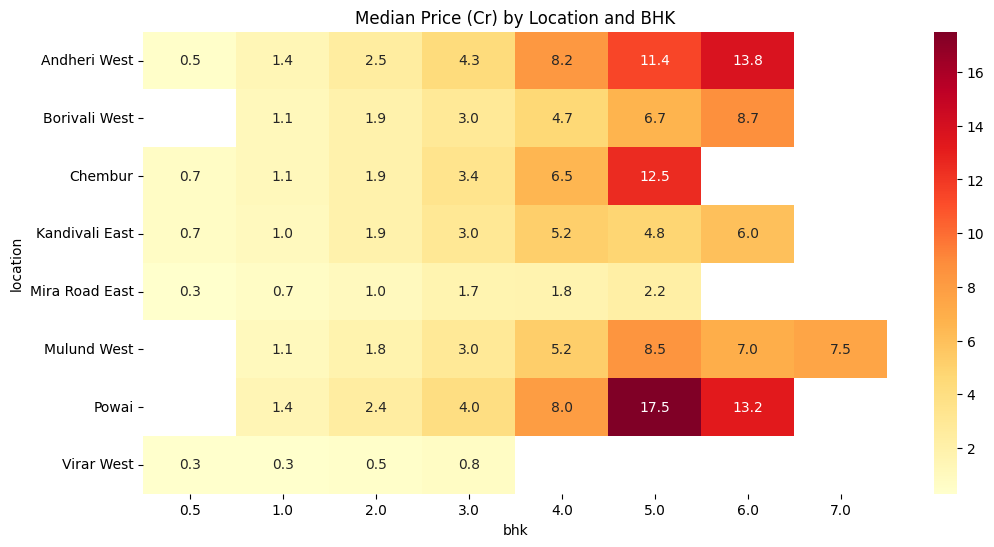

In [89]:
top_8 = df['location'].value_counts().head(8).index
pivot = df[df['location'].isin(top_8)].groupby(['location','bhk'])['price'].median().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Median Price (Cr) by Location and BHK')
plt.show()

### Insights: Median Price by Location and BHK

*   **Regional Multiplier:** Location acts as a massive price multiplier. A **3 BHK in Andheri West (~4.3 Cr)** or **Powai (~4.1 Cr)** is significantly more expensive than even a **5 BHK in Mira Road (~2.2 Cr)**.
*   **Affordability Ceiling:** In value hubs like **Virar West**, median prices remain under 1 Cr even for 3 BHK units, whereas in premium hubs, the *entry-level* 1 BHK starts above 1.4 Cr.
*   **Luxury Scalability:** Premium locations (Andheri, Powai, Mulund) show much steeper price escalations as BHK count increases, reflecting the 'luxury premium' added to larger units in high-demand zones.

In [90]:
df.head()

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category
0,3.0,2.05,15.0,Middle,Moroccan Cooperative,3.0,3.0,3.0,1.0,kaggle,Goregaon East,1862.0,1425.0,True,Semi Furnished,11009.667025,4,NaN,NaN,Mid (5-15)
1,1.0,1.33,1.0,Lower,Rajesh White City,1.0,2.0,0.0,1.0,kaggle,Kandivali East,790.0,479.0,True,Unfurnished,16835.443038,1,NaN,NaN,New (0-5)
2,3.0,7.30,10.0,Lower,Oberoi Esquire,3.0,2.0,0.0,2.0,kaggle,Goregaon East,1430.0,1330.0,True,Unfurnished,51048.951049,3,NaN,NaN,Mid (5-15)
3,3.0,7.60,4.0,Higher,Oberoi Esquire,3.0,4.0,0.0,3.0,kaggle,Goregaon East,2195.0,1400.0,True,Semi Furnished,34624.145786,5,NaN,NaN,New (0-5)
4,2.0,3.20,3.0,Lower,Ajmera Zeon,2.0,2.0,1.0,1.0,kaggle,Wadala East,960.0,860.0,True,Unfurnished,33333.333333,3,NaN,NaN,New (0-5)


## price vs buildup area by location

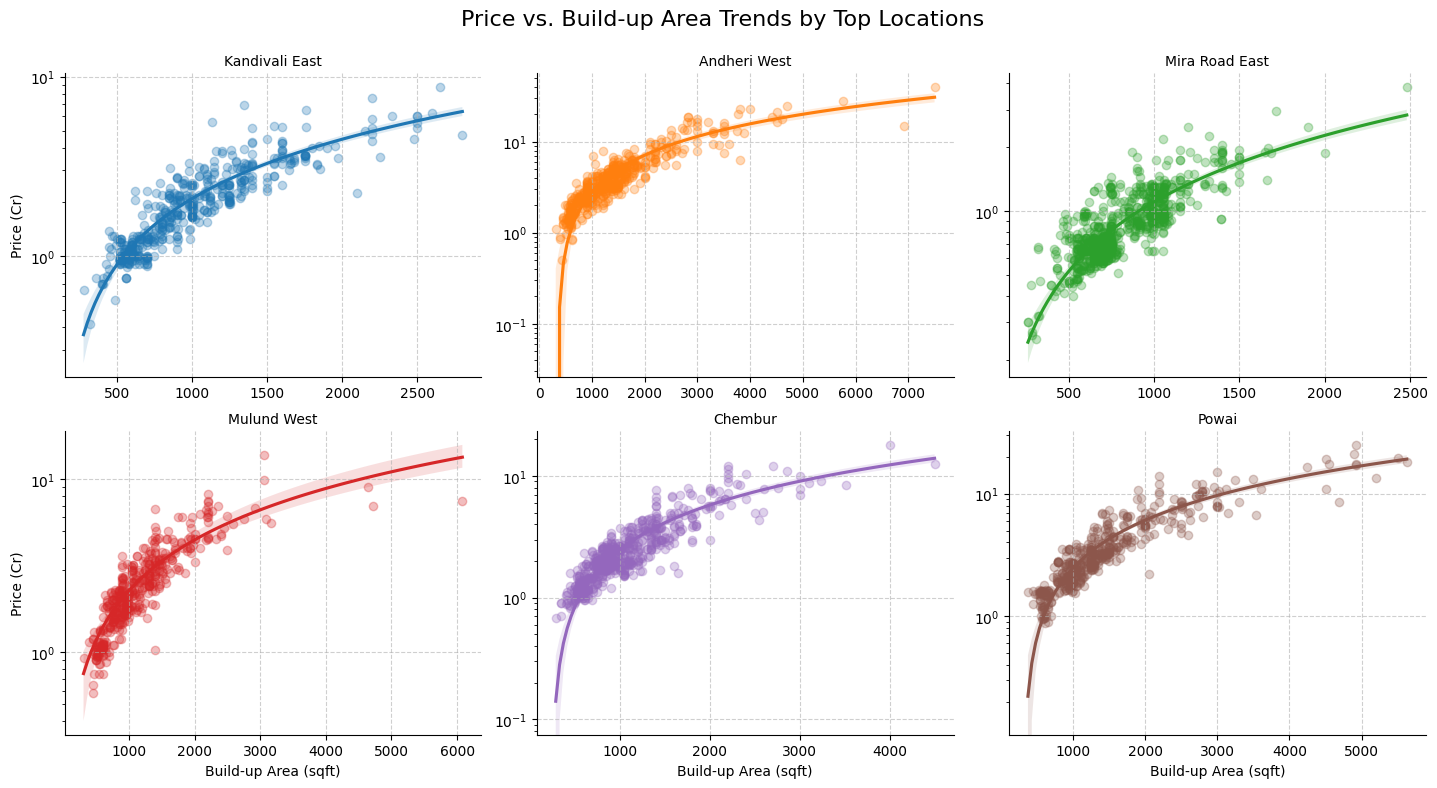

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for the top 6 locations to keep the visualization clean
top_6_locs = df['location'].value_counts().head(6).index
df_filtered = df[df['location'].isin(top_6_locs)]

# Create a faceted scatter plot with regression lines
g = sns.lmplot(
    data=df_filtered,
    x='buildup_area_sqft',
    y='price',
    col='location',
    hue='location',
    col_wrap=3,
    height=4,
    aspect=1.2,
    scatter_kws={'alpha': 0.3},
    facet_kws={'sharey': False, 'sharex': False}
)

# Adjust scales and labels
for ax in g.axes.flat:
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', alpha=0.6)

g.set_axis_labels("Build-up Area (sqft)", "Price (Cr)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Price vs. Build-up Area Trends by Top Locations', fontsize=16)
plt.show()

### Insights: Price vs. Build-up Area by Location

*   **Varying Slopes:** The 'steepness' of the regression lines confirms that an additional 500 sqft costs significantly more in **Andheri West** or **Powai** than in **Mira Road East**.
*   **Market Consistency:** Most locations show a tight linear relationship (on a log scale), indicating that area remains a primary and consistent price predictor within individual micro-markets.
*   **Price Ceiling/Floor:** Affordable zones like **Mira Road East** show a much tighter vertical clustering, whereas premium zones have a higher 'ceiling' for price regardless of the area, driven by luxury branding and specific project premiums.

In [103]:
df.to_csv('Real_Estate_EDA.csv', index=False)